# Clustering Techniques Analysis: Assignment 3

---

## PROGRAMMING ASSIGNMENT

### Task
You are provided with 15 different datasets. Your task is to determine which clustering techniques apply to each dataset and which do not.

### Datasets
- circles
- moons
- anisotropic
- varied_density
- blobs
- random
- spirals
- jain
- flame
- compound
- diamonds
- cross
- concentric_rings
- noisy_moons
- blobs_with_noise

### Clustering Techniques to Test
1. K-Means++
2. K-Medoids
3. Agglomerative (Single Linkage)
4. Agglomerative (Complete Linkage)
5. Agglomerative (Average Linkage)
6. Agglomerative (Ward Linkage)
7. DBSCAN

### Requirements
- Use coding with sklearn libraries or necessary libraries
- Determine which techniques work and which fail on each dataset
- Display the techniques that work and the ones that fail for each dataset

### Deliverables
**Save the notebook as: <your_name_Assignemnt3.ipynb**
- Code implementation
- Visual displays showing results

---

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
# from sklearn_extra.cluster import KMedoids
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


class DatasetGenerator:
    """
    Generates various synthetic datasets for clustering experiments.
    
    Parameters:
    -----------
    dataset_type : str
        Type of dataset to generate. Options:
        Basic shapes:
        - 'circles': Concentric circles
        - 'moons': Half moons
        - 'blobs': Standard Gaussian blobs
        - 'anisotropic': Elongated blobs
        - 'varied_density': Blobs with different densities
        - 'uneven_sizes': Clusters with different sizes
        - 'random': Random uniform distribution
        
        Complex patterns:
        - 'spirals': Intertwined spirals
        - 'jain': Two crescents with different densities
        - 'flame': Varying density clusters
        - 'compound': Six Gaussian clusters
        - 'diamonds': Diamond-shaped clusters
        - 'cross': X-shaped pattern
        - 'concentric_rings': Multiple concentric circles (3 rings)
        - 'grid': Grid pattern (9 clusters)
        - 'noisy_moons': Half moons with high noise
        - 'blobs_with_noise': Clusters with background noise
        
    n_samples : int, default=300
        Number of samples to generate
    noise : float, default=0.05
        Amount of noise to add
    random_state : int, default=42
        Random seed for reproducibility
    """
    
    def __init__(self, dataset_type, n_samples=300, noise=0.05, random_state=42):
        self.dataset_type = dataset_type.lower()
        self.n_samples = n_samples
        self.noise = noise
        self.random_state = random_state
        np.random.seed(random_state)
        
        # Validate dataset type
        valid_types = [
            # Basic
            'circles', 'moons', 'anisotropic', 'varied_density', 
            'uneven_sizes', 'random', 'blobs',
            # Complex
            'spirals', 'jain', 'flame', 'compound', 'diamonds',
            'cross', 'concentric_rings', 'grid', 'noisy_moons', 'blobs_with_noise'
        ]
        if self.dataset_type not in valid_types:
            raise ValueError(f"Invalid dataset_type. Choose from: {valid_types}")
        
        self.X = None
        self.y_true = None
        self.X_scaled = None
        self.n_clusters = None
        
    def generate(self):
        """Generate the dataset based on the specified type."""
        
        # Basic datasets
        if self.dataset_type == 'circles':
            self.X, self.y_true = make_circles(
                n_samples=self.n_samples, 
                factor=0.5, 
                noise=self.noise,
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'moons':
            self.X, self.y_true = make_moons(
                n_samples=self.n_samples, 
                noise=self.noise,
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'anisotropic':
            X, y = make_blobs(
                n_samples=self.n_samples, 
                centers=3, 
                random_state=self.random_state
            )
            transformation = [[0.6, -0.6], [-0.4, 0.8]]
            self.X = np.dot(X, transformation)
            self.y_true = y
            self.n_clusters = 3
            
        elif self.dataset_type == 'varied_density':
            self.X, self.y_true = make_blobs(
                n_samples=self.n_samples,
                centers=[[0, 0], [3, 3]],
                cluster_std=[0.5, 1.5],
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'uneven_sizes':
            self.X, self.y_true = make_blobs(
                n_samples=[100, 200],
                centers=[[0, 0], [4, 4]],
                cluster_std=[0.5, 1.0],
                random_state=self.random_state
            )
            self.n_clusters = 2
            
        elif self.dataset_type == 'random':
            self.X = np.random.rand(self.n_samples, 2) * 4 - 2
            self.y_true = np.zeros(self.n_samples, dtype=int)
            self.n_clusters = 2
            
        elif self.dataset_type == 'blobs':
            self.X, self.y_true = make_blobs(
                n_samples=self.n_samples,
                centers=3,
                cluster_std=0.6,
                random_state=self.random_state
            )
            self.n_clusters = 3
        
        # Complex datasets
        elif self.dataset_type == 'spirals':
            self._generate_spirals()
            
        elif self.dataset_type == 'jain':
            self._generate_jain()
            
        elif self.dataset_type == 'flame':
            self._generate_flame()
            
        elif self.dataset_type == 'compound':
            self._generate_compound()
            
        elif self.dataset_type == 'diamonds':
            self._generate_diamonds()
            
        elif self.dataset_type == 'cross':
            self._generate_cross()
            
        elif self.dataset_type == 'concentric_rings':
            self._generate_concentric_rings()
            
        elif self.dataset_type == 'grid':
            self._generate_grid()
            
        elif self.dataset_type == 'noisy_moons':
            self._generate_noisy_moons()
            
        elif self.dataset_type == 'blobs_with_noise':
            self._generate_blobs_with_noise()
        
        # Standardize features
        self.X_scaled = StandardScaler().fit_transform(self.X)
        
        return self
    
    def _generate_spirals(self):
        """Generate two intertwined spirals."""
        n_points = self.n_samples // 2
        theta = np.linspace(0, 4 * np.pi, n_points)
        
        # Spiral 1
        r1 = theta
        x1 = r1 * np.cos(theta) + np.random.randn(n_points) * self.noise * 5
        y1 = r1 * np.sin(theta) + np.random.randn(n_points) * self.noise * 5
        
        # Spiral 2 (rotated by pi)
        r2 = theta
        x2 = r2 * np.cos(theta + np.pi) + np.random.randn(n_points) * self.noise * 5
        y2 = r2 * np.sin(theta + np.pi) + np.random.randn(n_points) * self.noise * 5
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_points), np.ones(n_points)])
        self.n_clusters = 2
    
    def _generate_jain(self):
        """Generate Jain dataset: two crescents with different densities."""
        # Dense crescent
        n_dense = int(self.n_samples * 0.7)
        theta1 = np.linspace(0, np.pi, n_dense)
        r1 = 1
        x1 = r1 * np.cos(theta1) + np.random.randn(n_dense) * self.noise
        y1 = r1 * np.sin(theta1) + np.random.randn(n_dense) * self.noise
        
        # Sparse crescent
        n_sparse = self.n_samples - n_dense
        theta2 = np.linspace(0, np.pi, n_sparse)
        r2 = 2
        x2 = r2 * np.cos(theta2) + 1 + np.random.randn(n_sparse) * self.noise
        y2 = r2 * np.sin(theta2) - 1 + np.random.randn(n_sparse) * self.noise
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_dense), np.ones(n_sparse)])
        self.n_clusters = 2
    
    def _generate_flame(self):
        """Generate flame-shaped dataset with varying density."""
        n_per_cluster = self.n_samples // 2
        
        # Dense flame base
        x1 = np.random.randn(n_per_cluster) * 0.3
        y1 = np.random.randn(n_per_cluster) * 0.3
        
        # Sparse flame tip
        x2 = np.random.randn(n_per_cluster) * 0.8 + 2
        y2 = np.random.randn(n_per_cluster) * 1.5 + 1
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_cluster), np.ones(n_per_cluster)])
        self.n_clusters = 2
    
    def _generate_compound(self):
        """Generate six Gaussian clusters (compound dataset)."""
        centers = [[0, 0], [0, 3], [3, 0], [3, 3], [1.5, 1.5], [4.5, 1.5]]
        self.X, self.y_true = make_blobs(
            n_samples=self.n_samples,
            centers=centers,
            cluster_std=0.3,
            random_state=self.random_state
        )
        self.n_clusters = 6
    
    def _generate_diamonds(self):
        """Generate two diamond-shaped clusters."""
        n_per_cluster = self.n_samples // 2
        
        # Diamond 1
        t1 = np.linspace(0, 2*np.pi, n_per_cluster)
        r1 = 1 + 0.5 * np.abs(np.sin(4*t1))
        x1 = r1 * np.cos(t1) + np.random.randn(n_per_cluster) * self.noise
        y1 = r1 * np.sin(t1) + np.random.randn(n_per_cluster) * self.noise
        
        # Diamond 2 (shifted)
        t2 = np.linspace(0, 2*np.pi, n_per_cluster)
        r2 = 1 + 0.5 * np.abs(np.sin(4*t2))
        x2 = r2 * np.cos(t2) + 4 + np.random.randn(n_per_cluster) * self.noise
        y2 = r2 * np.sin(t2) + np.random.randn(n_per_cluster) * self.noise
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_cluster), np.ones(n_per_cluster)])
        self.n_clusters = 2
    
    def _generate_cross(self):
        """Generate X-shaped (cross) pattern."""
        n_per_line = self.n_samples // 2
        
        # Line 1: y = x
        x1 = np.linspace(-2, 2, n_per_line)
        y1 = x1 + np.random.randn(n_per_line) * self.noise * 2
        
        # Line 2: y = -x
        x2 = np.linspace(-2, 2, n_per_line)
        y2 = -x2 + np.random.randn(n_per_line) * self.noise * 2
        
        self.X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
        self.y_true = np.hstack([np.zeros(n_per_line), np.ones(n_per_line)])
        self.n_clusters = 2
    
    def _generate_concentric_rings(self):
        """Generate multiple concentric rings."""
        n_per_ring = self.n_samples // 3
        
        rings = []
        labels = []
        for i, radius in enumerate([1, 2, 3]):
            theta = np.linspace(0, 2*np.pi, n_per_ring)
            x = radius * np.cos(theta) + np.random.randn(n_per_ring) * self.noise
            y = radius * np.sin(theta) + np.random.randn(n_per_ring) * self.noise
            rings.append(np.column_stack([x, y]))
            labels.append(np.ones(n_per_ring) * i)
        
        self.X = np.vstack(rings)
        self.y_true = np.hstack(labels)
        self.n_clusters = 3
    
    def _generate_grid(self):
        """Generate grid pattern."""
        grid_size = 3  # 3x3 grid
        n_per_cell = self.n_samples // (grid_size ** 2)
        
        points = []
        labels = []
        label_id = 0
        
        for i in range(grid_size):
            for j in range(grid_size):
                x = np.random.randn(n_per_cell) * 0.2 + i * 2
                y = np.random.randn(n_per_cell) * 0.2 + j * 2
                points.append(np.column_stack([x, y]))
                labels.append(np.ones(n_per_cell) * label_id)
                label_id += 1
        
        self.X = np.vstack(points)
        self.y_true = np.hstack(labels)
        self.n_clusters = grid_size ** 2
    
    def _generate_noisy_moons(self):
        """Generate half moons with high noise."""
        self.X, self.y_true = make_moons(
            n_samples=self.n_samples,
            noise=0.15,  # High noise
            random_state=self.random_state
        )
        self.n_clusters = 2
    
    def _generate_blobs_with_noise(self):
        """Generate blobs with uniform background noise."""
        n_signal = int(self.n_samples * 0.7)
        n_noise = self.n_samples - n_signal
        
        # Clean blobs
        X_signal, y_signal = make_blobs(
            n_samples=n_signal,
            centers=3,
            cluster_std=0.5,
            random_state=self.random_state
        )
        
        # Uniform noise
        X_noise = np.random.rand(n_noise, 2) * 10 - 5
        y_noise = np.ones(n_noise) * -1  # Label as noise
        
        self.X = np.vstack([X_signal, X_noise])
        self.y_true = np.hstack([y_signal, y_noise])
        self.n_clusters = 3
    
    def get_data(self, scaled=True):
        """
        Get the generated data.
        
        Parameters:
        -----------
        scaled : bool, default=True
            If True, return standardized data. Otherwise, return raw data.
        
        Returns:
        --------
        X : ndarray
            Feature matrix
        y_true : ndarray
            True labels (for reference)
        n_clusters : int
            Number of clusters
        """
        if self.X is None:
            raise ValueError("Data not generated yet. Call generate() first.")
        
        if scaled:
            return self.X_scaled, self.y_true, self.n_clusters
        else:
            return self.X, self.y_true, self.n_clusters
    
    def get_info(self):
        """Get information about the dataset."""
        if self.X is None:
            return "Dataset not generated yet."
        
        return {
            'type': self.dataset_type,
            'n_samples': len(self.X),
            'n_features': self.X.shape[1],
            'n_clusters': self.n_clusters,
            'scaled': self.X_scaled is not None
        }

In [8]:
# KMeans++ from Clustering1.ipynb

class KMeansPlusPlus:
    def __init__(self, k, first_centroid=None, max_iterations=100):
        self.k = k
        self.first_centroid = first_centroid
        self.max_iterations = max_iterations
        self.centroids_history = []
        self.labels_history = []
        
    def fit(self, X):
        n_samples = X.shape[0]
        
        # Initialize first centroid
        if self.first_centroid is not None:
            centroids = [np.array(self.first_centroid, dtype=float)]
        else:
            centroids = [X[np.random.randint(n_samples)].copy()]
        
        # K-Means++ initialization for remaining centroids
        for _ in range(1, self.k):
            distances = np.array([min([np.linalg.norm(x - c)**2 for c in centroids]) for x in X])
            probabilities = distances / distances.sum()
            cumulative_probs = np.cumsum(probabilities)
            r = np.random.rand()
            
            for idx, prob in enumerate(cumulative_probs):
                if r < prob:
                    centroids.append(X[idx].copy())
                    break
        
        self.centroids = np.array(centroids)
        self.centroids_history.append(self.centroids.copy())
        
        # Standard K-Means iterations
        for iteration in range(self.max_iterations):
            labels = self._assign_clusters(X)
            self.labels_history.append(labels)
            
            old_centroids = self.centroids.copy()
            for i in range(self.k):
                self.centroids[i] = X[labels == i].mean(axis=0)
            
            self.centroids_history.append(self.centroids.copy())
            
            shift = np.linalg.norm(self.centroids - old_centroids)
            if shift < 1e-4:
                print(f"K-Means++ converged in {iteration + 1} iterations")
                break
        
        self.labels_ = labels
        return self
    
    def _assign_clusters(self, X):
        distances = np.array([[np.linalg.norm(x - c) for c in self.centroids] for x in X])
        return np.argmin(distances, axis=1)


def generate_data(n_samples=300, noise_level=0.5, random_state=42):
    """Generate customer data: Age vs Spending Score"""
    np.random.seed(random_state)
    
    cov = [[20 * (1 + noise_level), 5], [5, 40 * (1 + noise_level)]]
    
    # 4 customer segments
    c1 = np.random.multivariate_normal([25, 75], cov, n_samples//4)  # Young high spenders
    c2 = np.random.multivariate_normal([25, 25], cov, n_samples//4)  # Young low spenders
    c3 = np.random.multivariate_normal([55, 75], cov, n_samples//4)  # Old high spenders
    c4 = np.random.multivariate_normal([55, 25], cov, n_samples//4)  # Old low spenders
    
    data = np.vstack([c1, c2, c3, c4])
    data[:, 0] = np.clip(data[:, 0], 18, 70)  # Age: 18-70
    data[:, 1] = np.clip(data[:, 1], 0, 100)  # Spending: 0-100
    
    return data


def plot_data(X):
    """Visualize original data"""
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c='steelblue', alpha=0.6, s=50, edgecolors='navy')
    plt.xlabel('Age', fontsize=12, fontweight='bold')
    plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
    plt.title('Original Customer Data', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_iterations(X, model, title):
    """Visualize centroid shifts across iterations"""
    n_iterations = len(model.centroids_history) - 1
    colors = plt.cm.Set1(np.linspace(0, 1, model.k))
    
    # Calculate grid size
    n_cols = 3
    n_rows = (n_iterations + n_cols) // n_cols
    
    fig = plt.figure(figsize=(15, 5 * n_rows))
    
    for iter_num in range(n_iterations + 1):
        ax = plt.subplot(n_rows, n_cols, iter_num + 1)
        
        # Plot points
        if iter_num > 0:
            labels = model.labels_history[iter_num - 1]
            for i in range(model.k):
                mask = labels == i
                ax.scatter(X[mask, 0], X[mask, 1], c=[colors[i]], alpha=0.5, s=40)
        else:
            ax.scatter(X[:, 0], X[:, 1], c='lightgray', alpha=0.5, s=40)
        
        # Plot centroids
        centroids = model.centroids_history[iter_num]
        ax.scatter(centroids[:, 0], centroids[:, 1], 
                  c='black', marker='X', s=400, 
                  edgecolors='yellow', linewidths=3, zorder=5)
        
        # Show centroid movement
        if iter_num > 0:
            old_centroids = model.centroids_history[iter_num - 1]
            for i in range(model.k):
                ax.arrow(old_centroids[i, 0], old_centroids[i, 1],
                        centroids[i, 0] - old_centroids[i, 0],
                        centroids[i, 1] - old_centroids[i, 1],
                        head_width=2, head_length=1.5, fc='blue', ec='blue', 
                        linewidth=2, alpha=0.7, length_includes_head=True)
        
        # Label centroids
        for i, c in enumerate(centroids):
            ax.text(c[0], c[1], f'C{i+1}', ha='center', va='center',
                   fontsize=9, fontweight='bold', color='white')
        
        ax.set_xlabel('Age', fontweight='bold')
        ax.set_ylabel('Spending Score', fontweight='bold')
        ax.set_title(f'Iteration {iter_num}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


In [9]:
# From Clustering2.ipynb
# ==================== VISUALIZATION ====================

def plot_clusters(X, labels, title):
    """Plot clustering results"""
    plt.figure(figsize=(10, 7))
    
    unique_labels = set(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(sorted(unique_labels)):
        if label == -1:
            # Noise points (DBSCAN only)
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c='black', alpha=0.3, s=30, marker='x', label='Noise')
        else:
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c=[colors[i]], alpha=0.6, s=50,
                       label=f'Cluster {label}', edgecolors='black', linewidth=0.5)
    
    plt.xlabel('Age', fontsize=12, fontweight='bold')
    plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==================== AGGLOMERATIVE CLUSTERING ====================

def apply_agglomerative(X, n_clusters=4, linkage_type='ward'):
    """Apply Agglomerative Clustering"""
    print(f"\nAgglomerative Clustering (linkage={linkage_type}):")
    
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_type)
    labels = model.fit_predict(X)
    
    # Print cluster sizes
    for i in range(n_clusters):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} points")
    
    return labels


CLUSTERING COMPARISON: Hierarchical vs Partitional Methods
Testing 15 different dataset types

📊 Showing all original datasets...


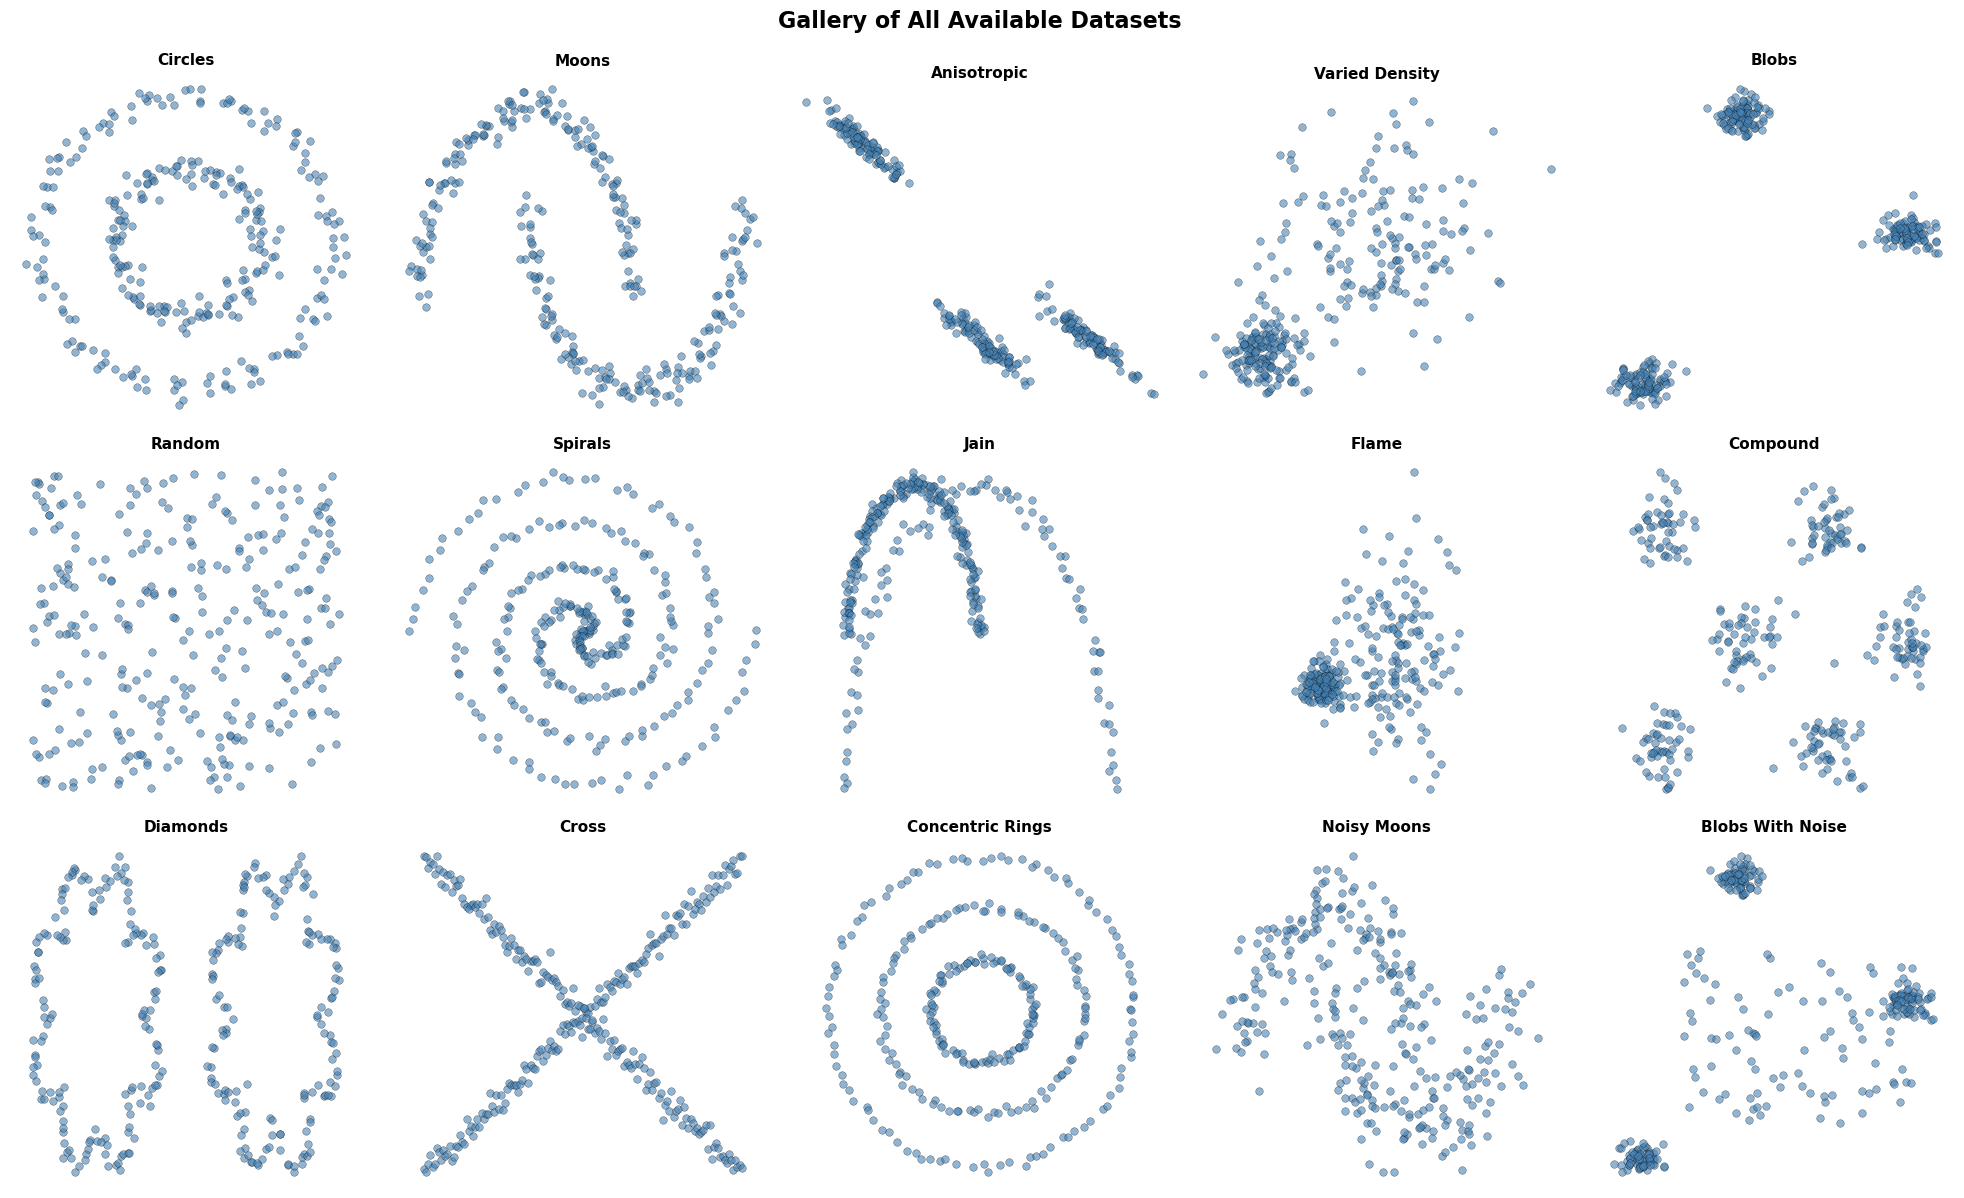


Agglomerative Clustering (linkage=single):
  Cluster 0: 150 points
  Cluster 1: 150 points


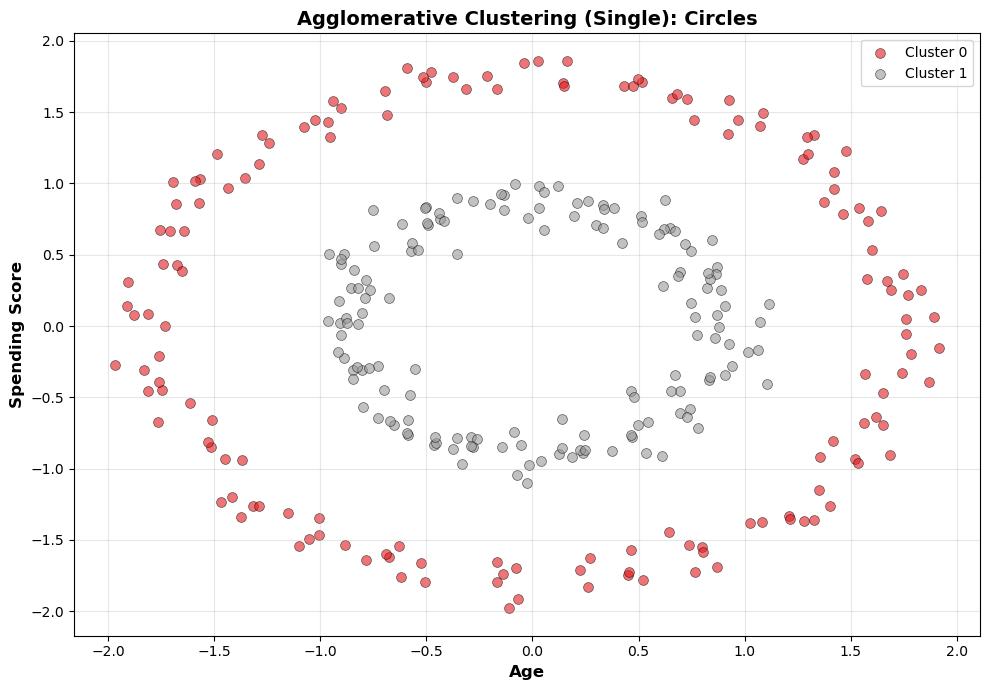


Agglomerative Clustering (linkage=complete):
  Cluster 0: 154 points
  Cluster 1: 146 points


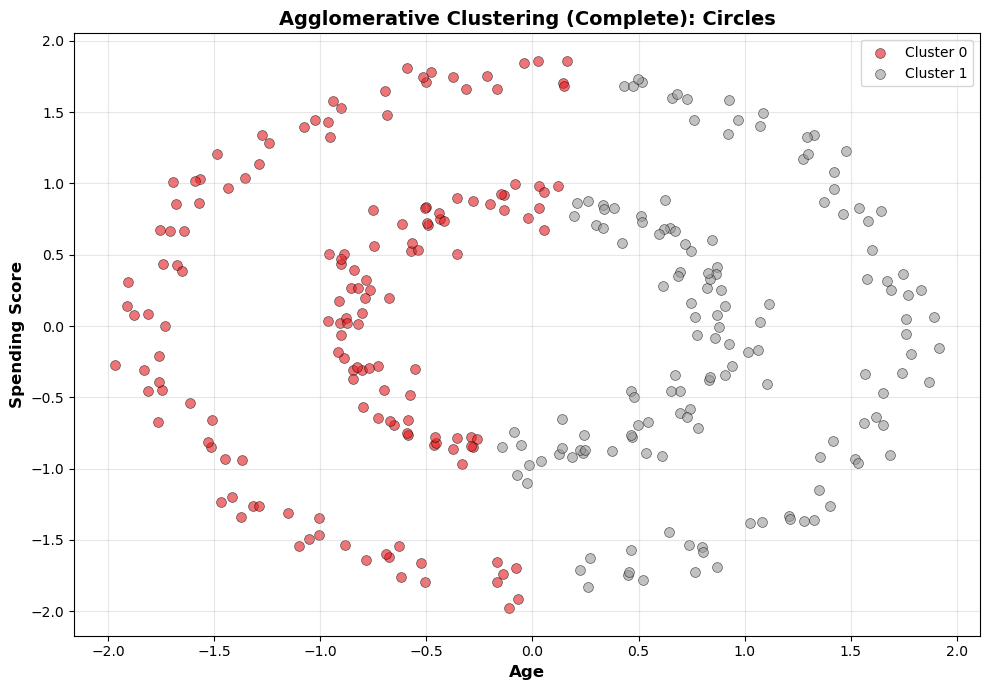


Agglomerative Clustering (linkage=average):
  Cluster 0: 198 points
  Cluster 1: 102 points


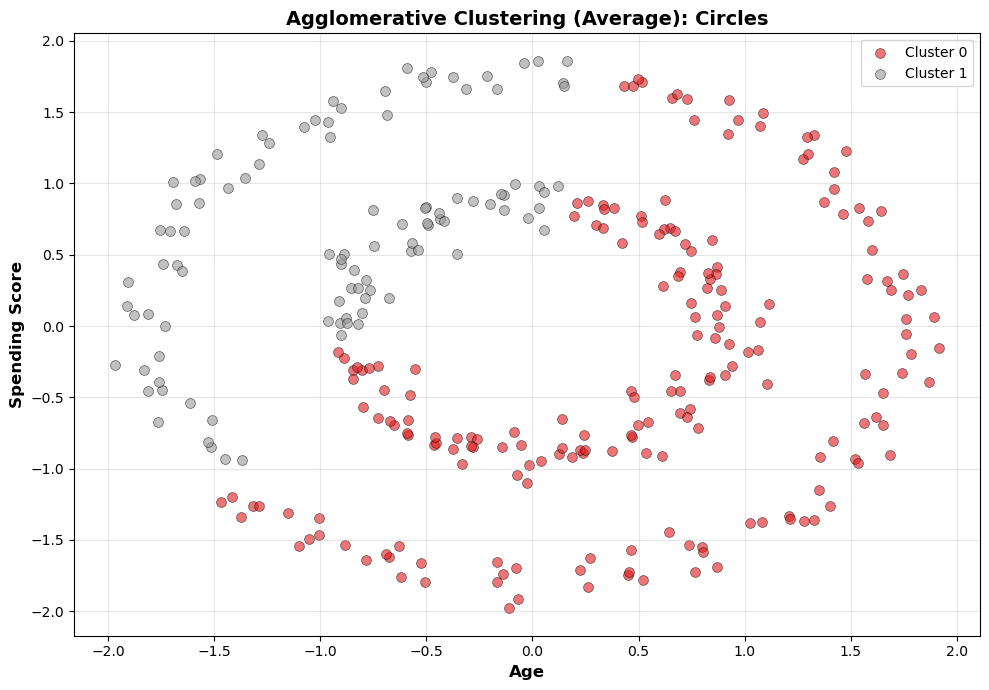


Agglomerative Clustering (linkage=ward):
  Cluster 0: 182 points
  Cluster 1: 118 points


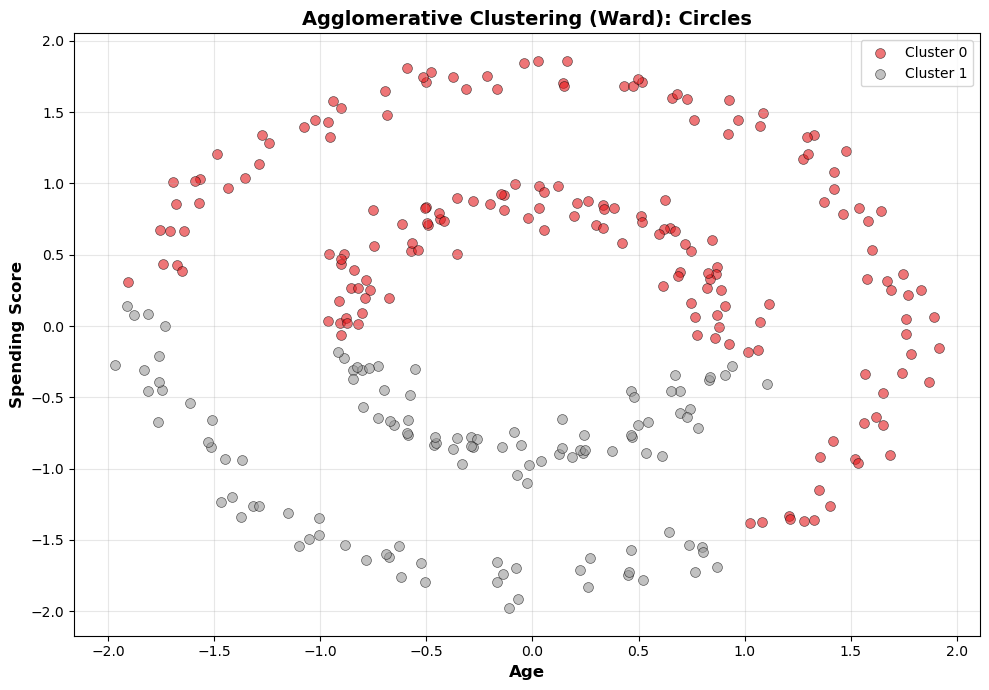


Agglomerative Clustering (linkage=single):
  Cluster 0: 150 points
  Cluster 1: 150 points


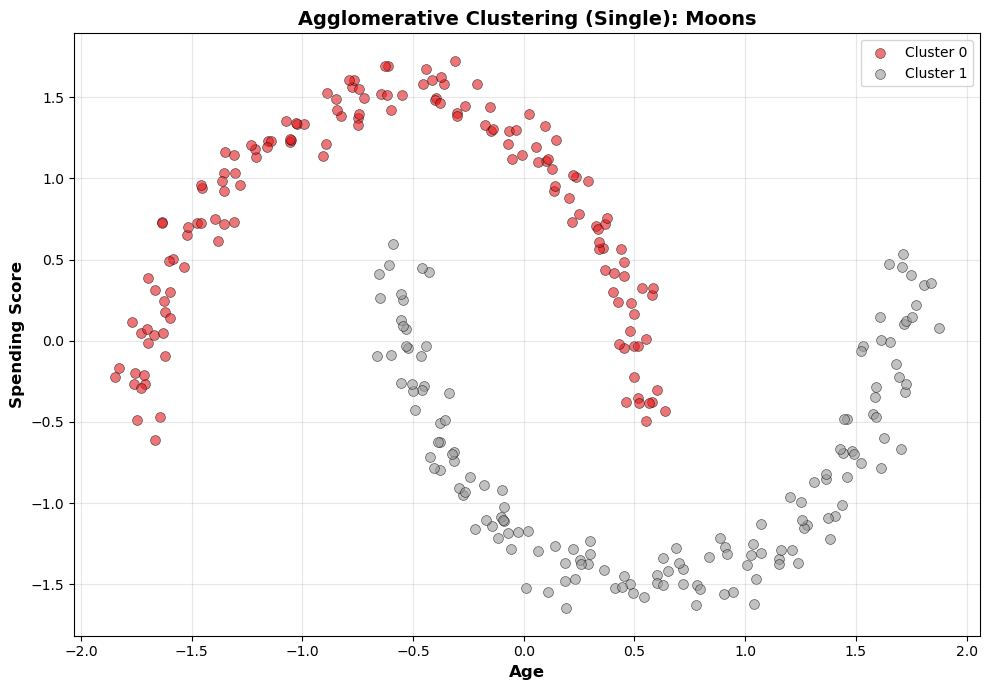


Agglomerative Clustering (linkage=complete):
  Cluster 0: 131 points
  Cluster 1: 169 points


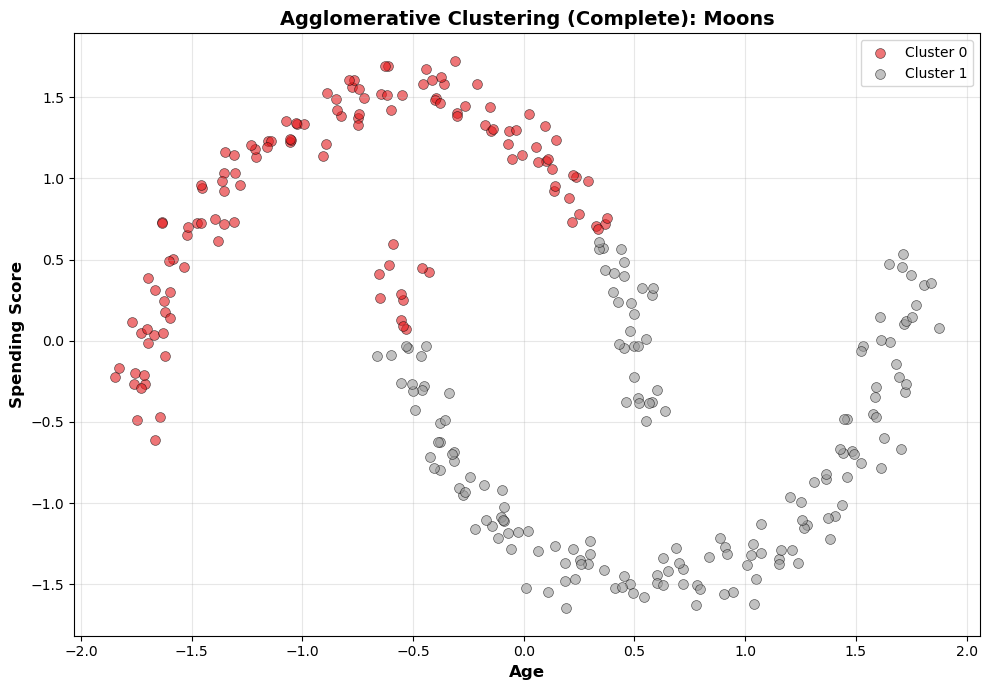


Agglomerative Clustering (linkage=average):
  Cluster 0: 176 points
  Cluster 1: 124 points


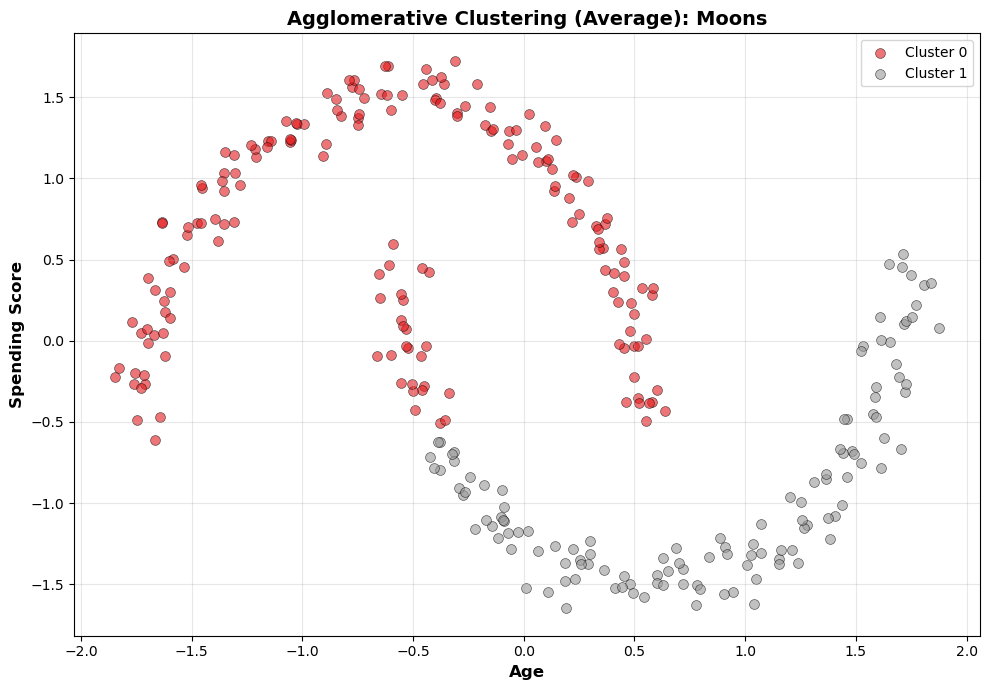


Agglomerative Clustering (linkage=ward):
  Cluster 0: 190 points
  Cluster 1: 110 points


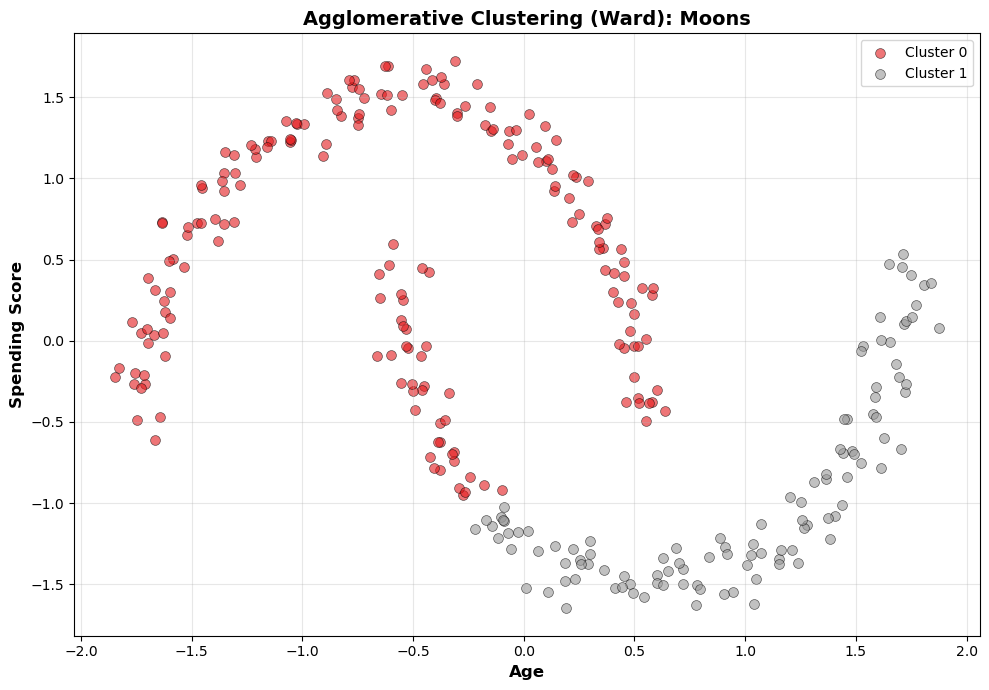


Agglomerative Clustering (linkage=single):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


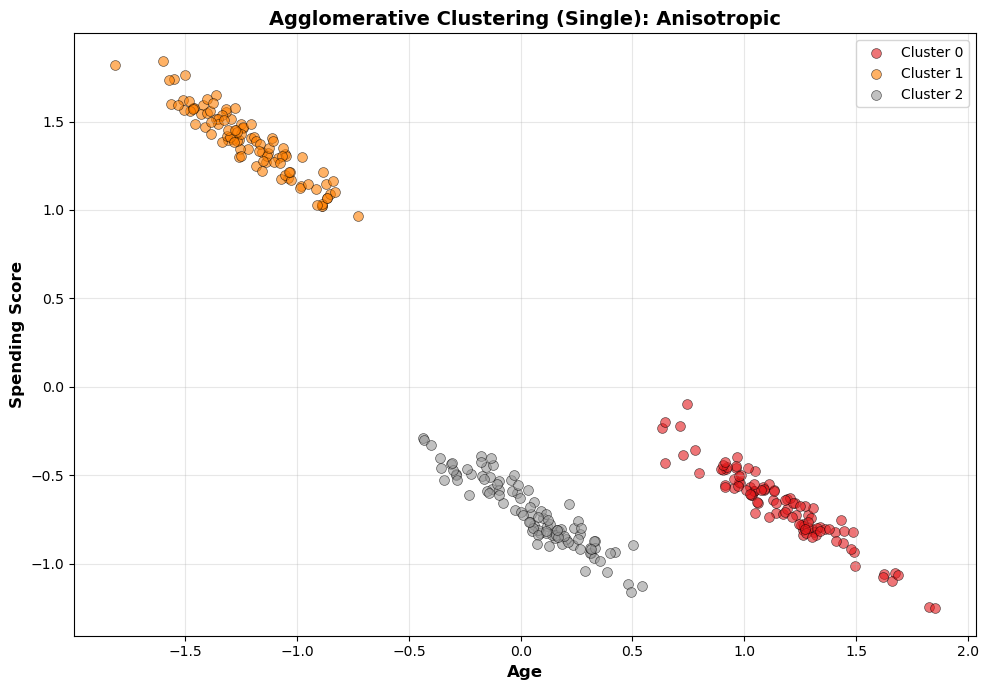


Agglomerative Clustering (linkage=complete):
  Cluster 0: 121 points
  Cluster 1: 100 points
  Cluster 2: 79 points


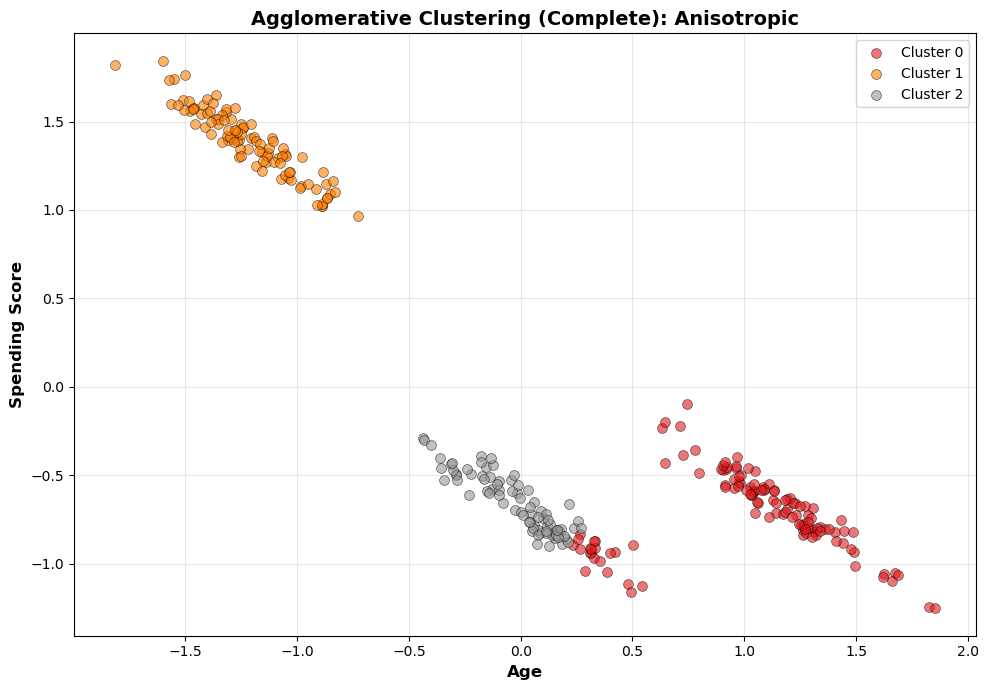


Agglomerative Clustering (linkage=average):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


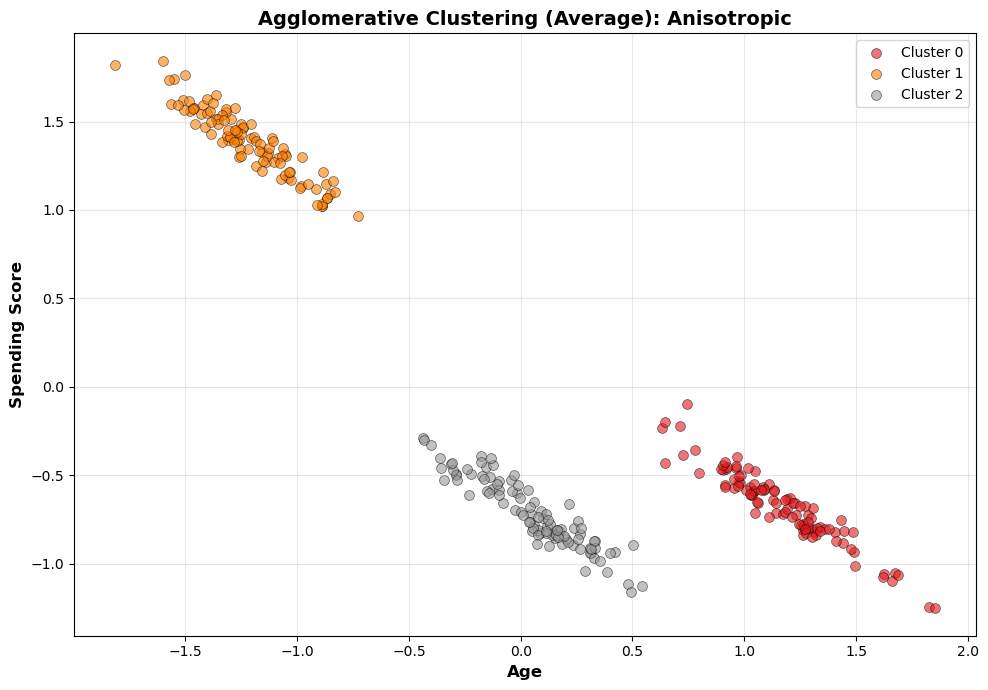


Agglomerative Clustering (linkage=ward):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


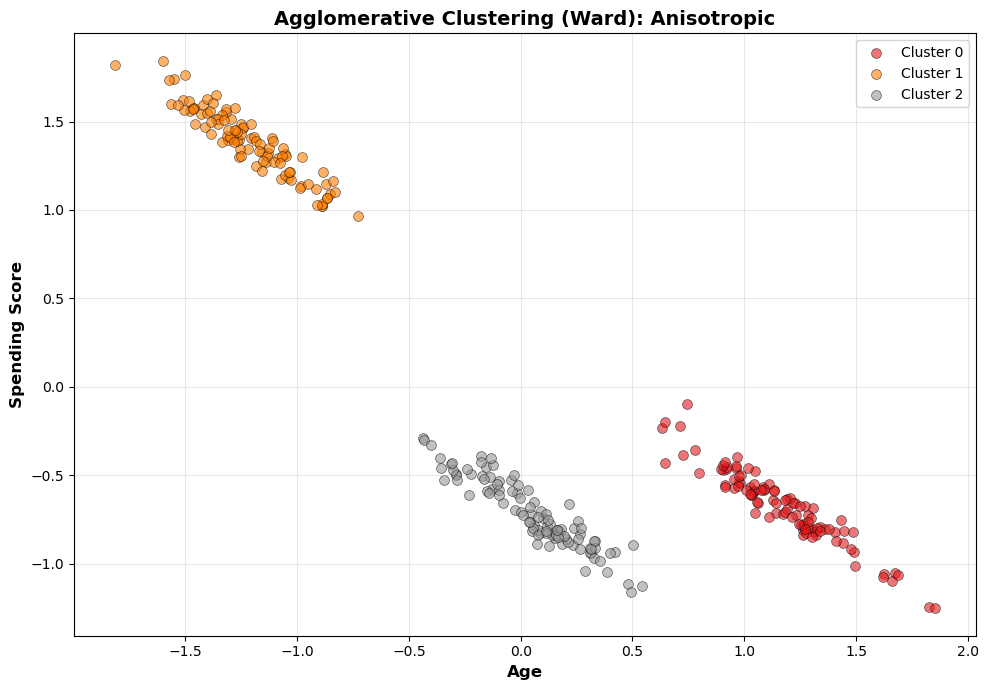


Agglomerative Clustering (linkage=single):
  Cluster 0: 299 points
  Cluster 1: 1 points


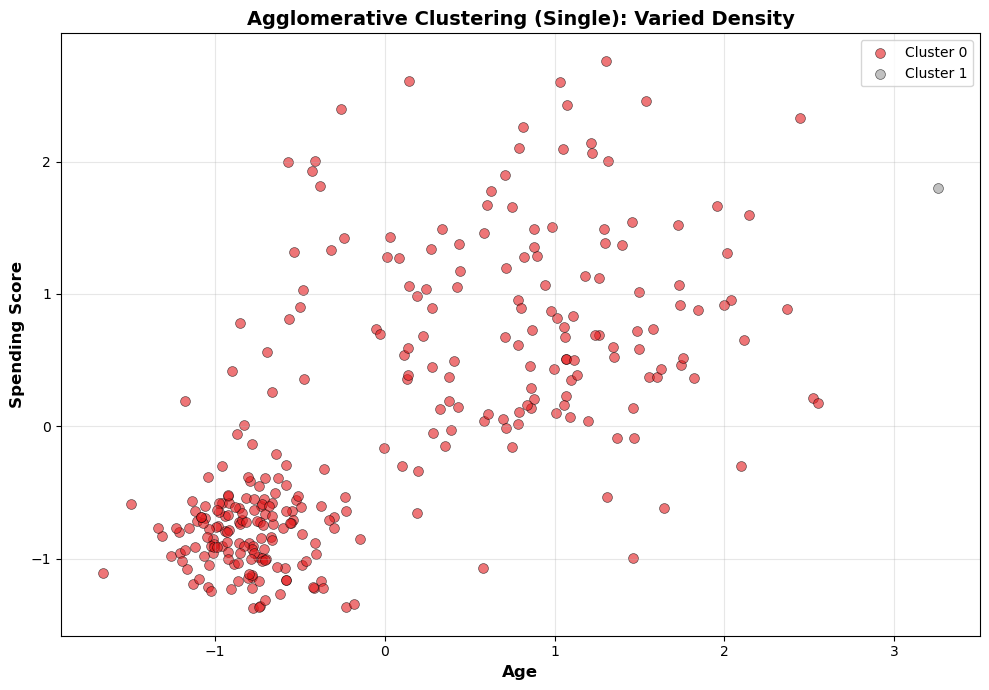


Agglomerative Clustering (linkage=complete):
  Cluster 0: 62 points
  Cluster 1: 238 points


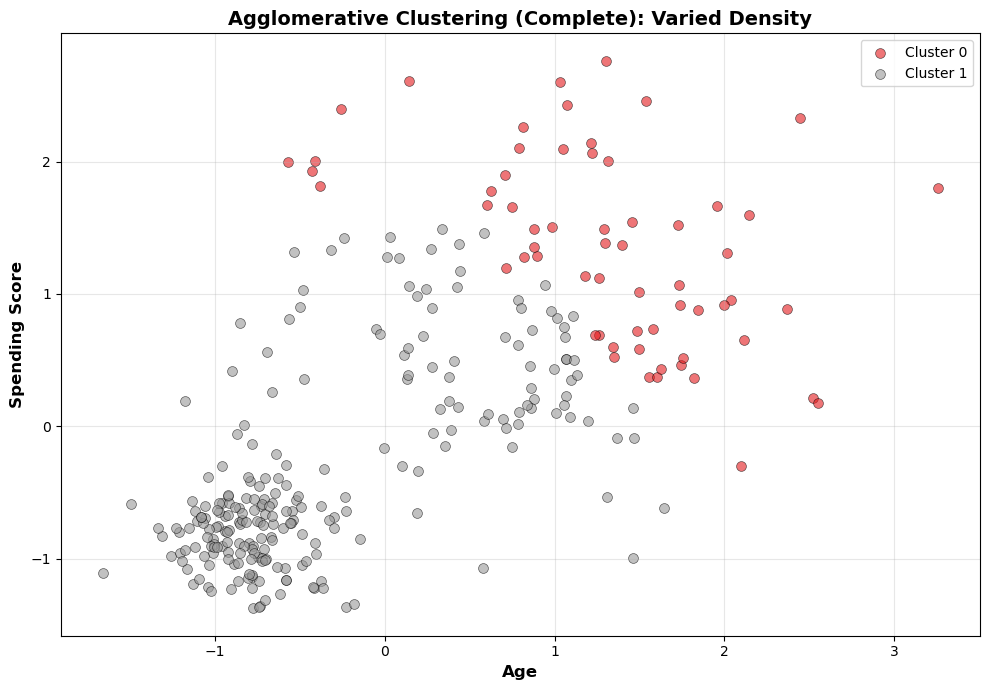


Agglomerative Clustering (linkage=average):
  Cluster 0: 298 points
  Cluster 1: 2 points


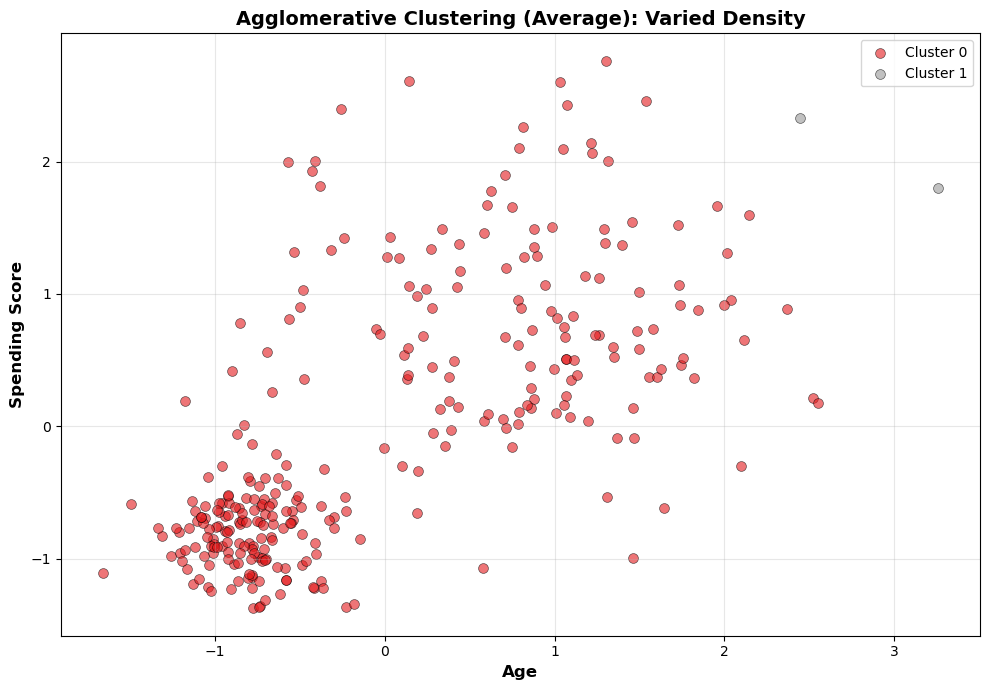


Agglomerative Clustering (linkage=ward):
  Cluster 0: 142 points
  Cluster 1: 158 points


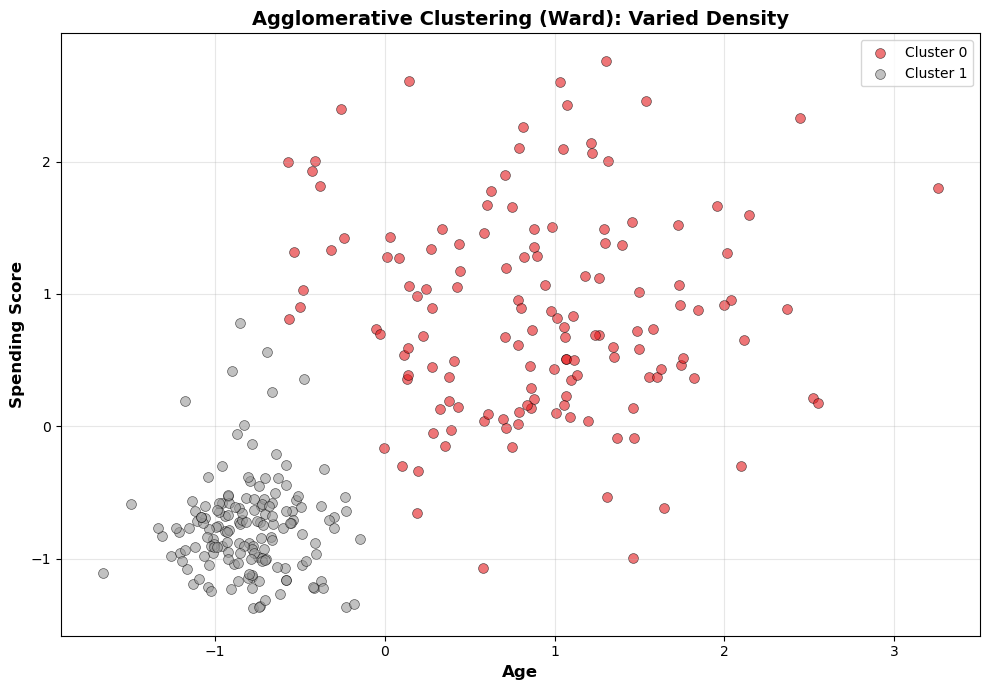


Agglomerative Clustering (linkage=single):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


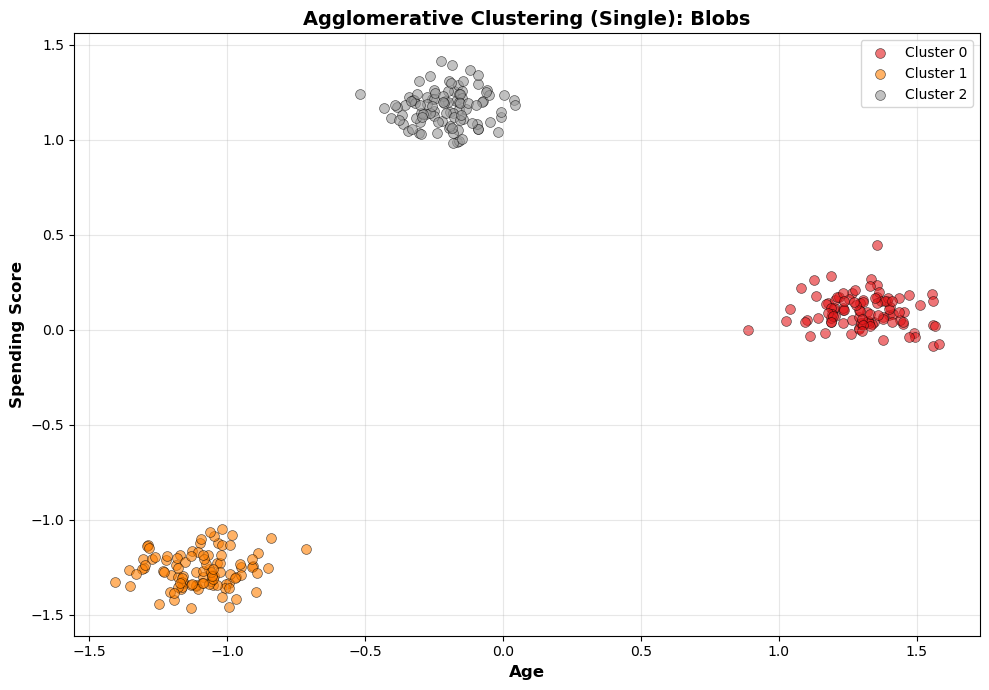


Agglomerative Clustering (linkage=complete):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


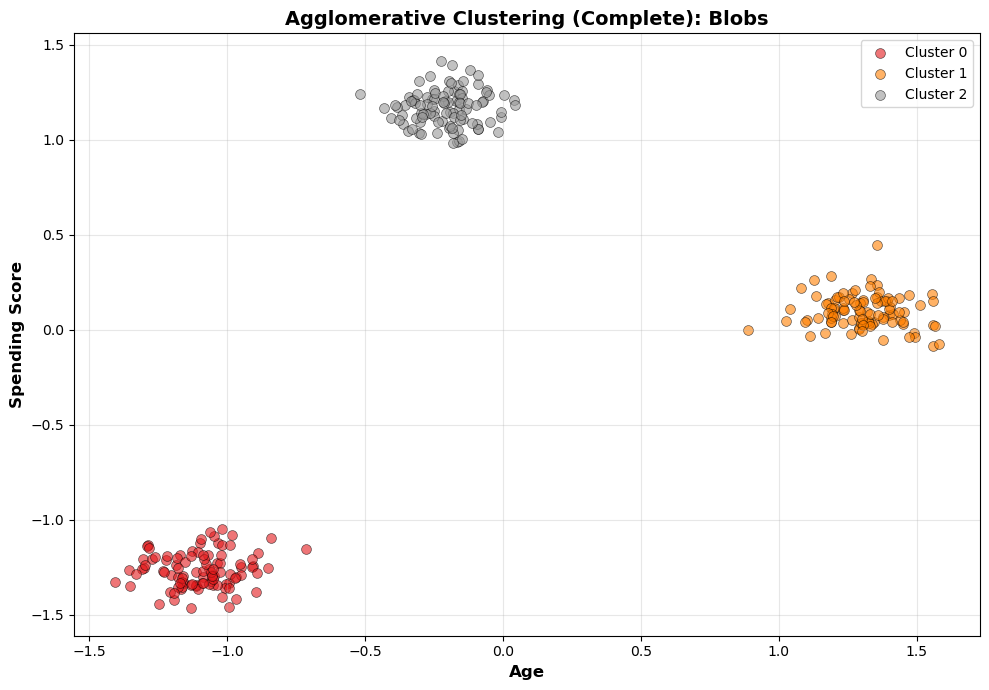


Agglomerative Clustering (linkage=average):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


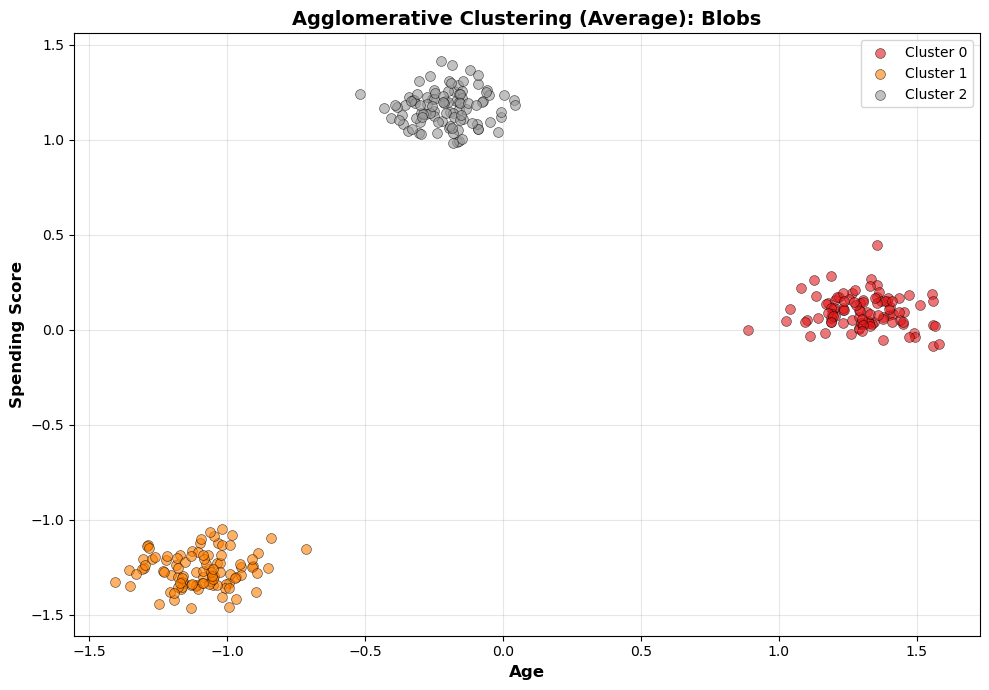


Agglomerative Clustering (linkage=ward):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


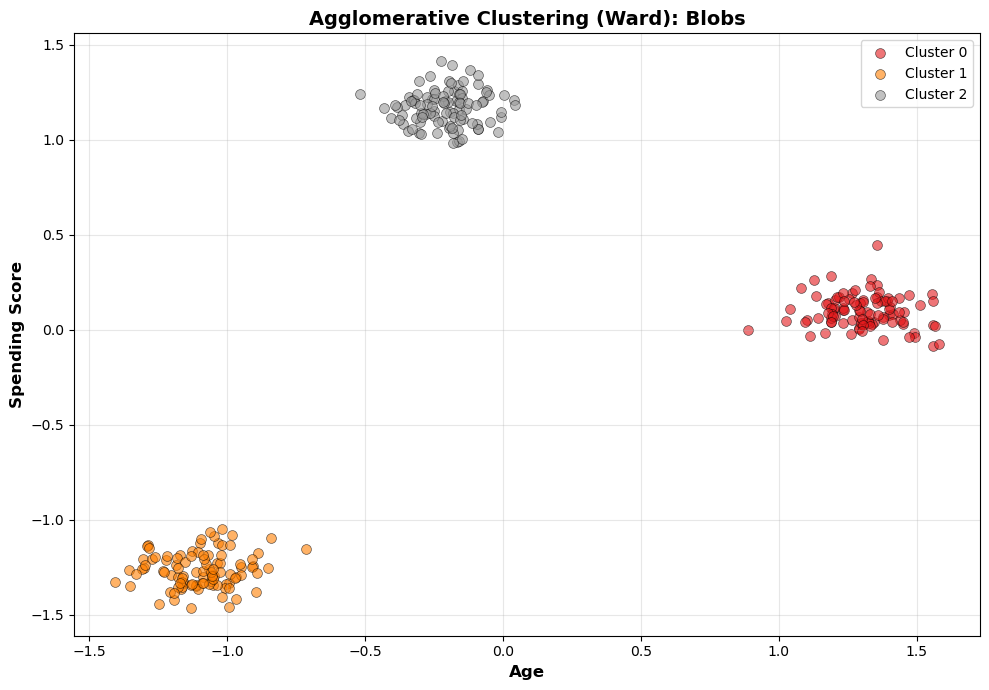


Agglomerative Clustering (linkage=single):
  Cluster 0: 297 points
  Cluster 1: 3 points


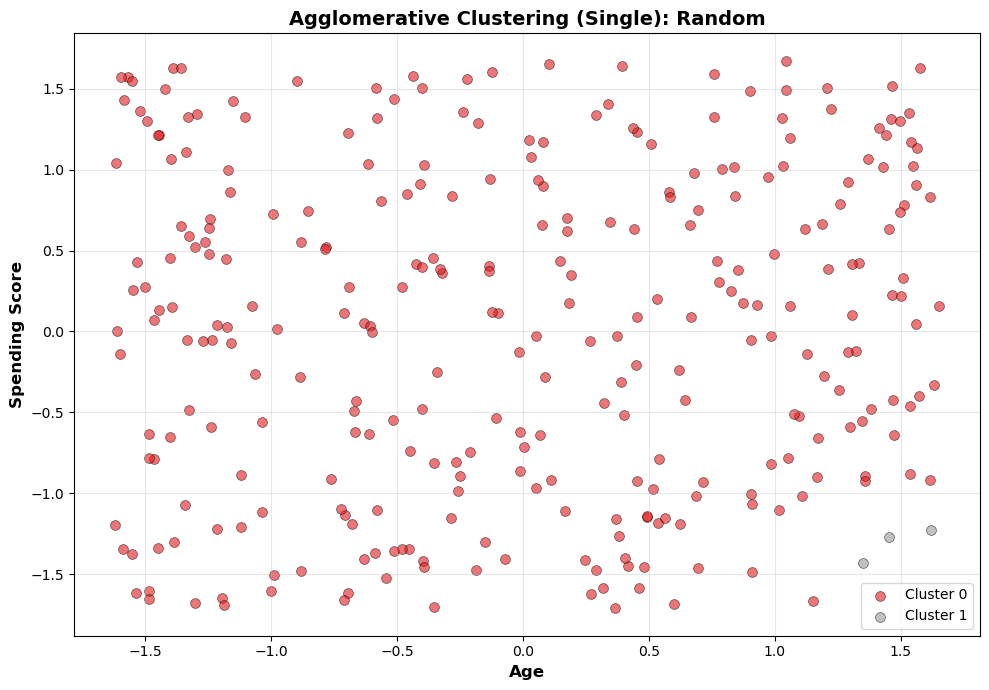


Agglomerative Clustering (linkage=complete):
  Cluster 0: 144 points
  Cluster 1: 156 points


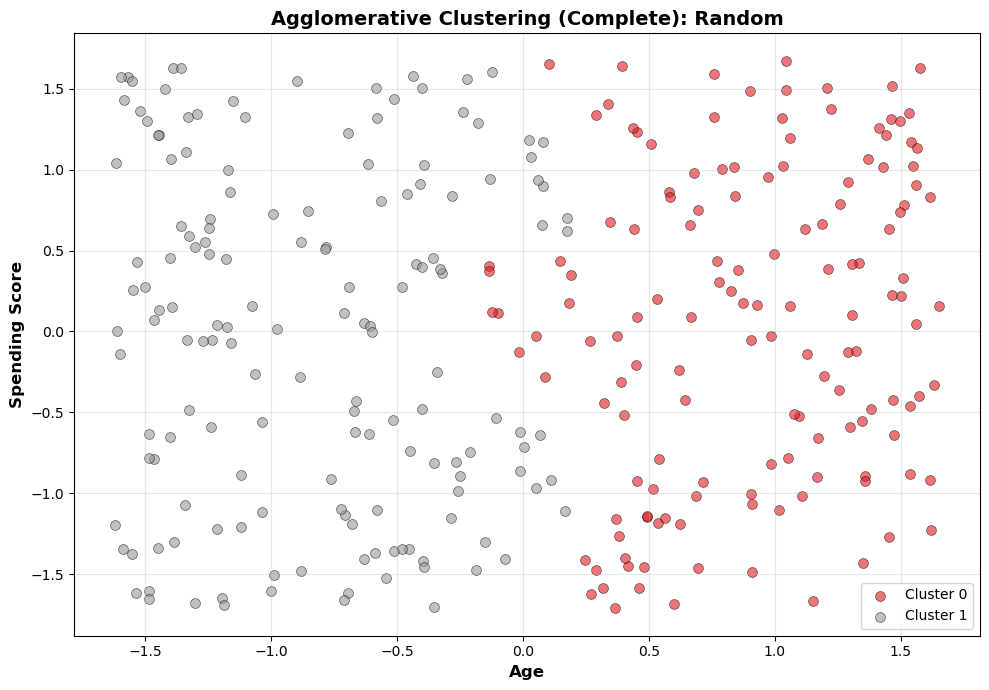


Agglomerative Clustering (linkage=average):
  Cluster 0: 162 points
  Cluster 1: 138 points


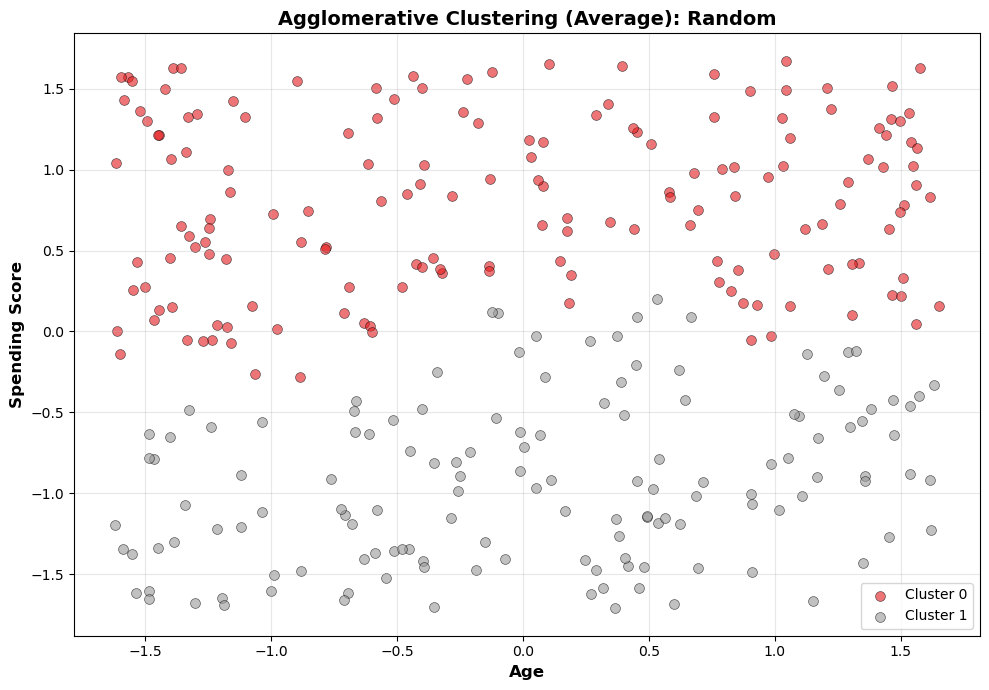


Agglomerative Clustering (linkage=ward):
  Cluster 0: 176 points
  Cluster 1: 124 points


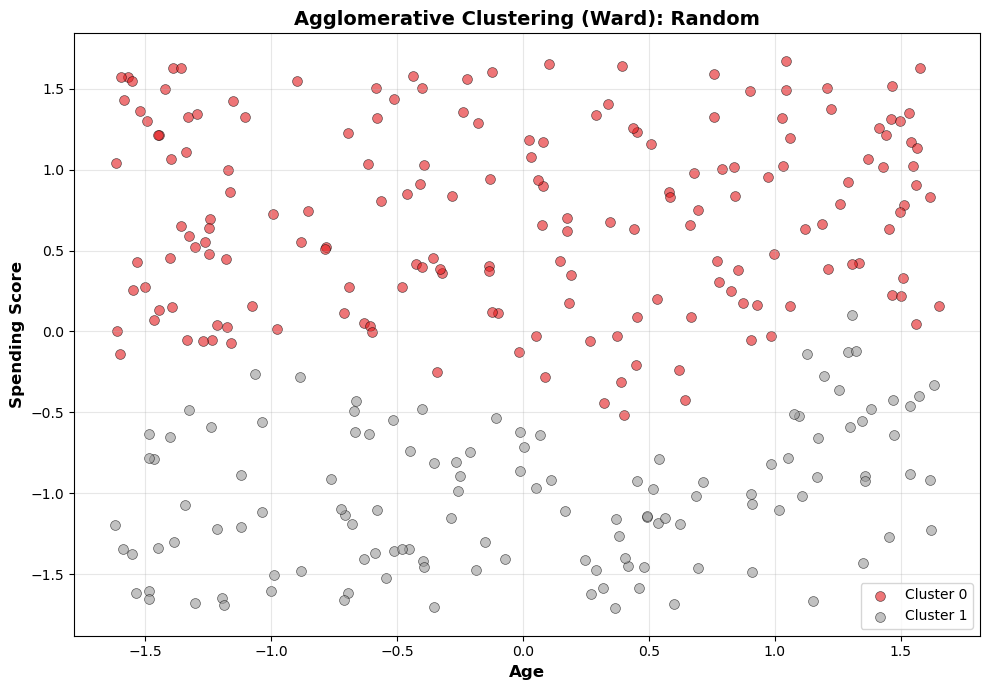


Agglomerative Clustering (linkage=single):
  Cluster 0: 279 points
  Cluster 1: 21 points


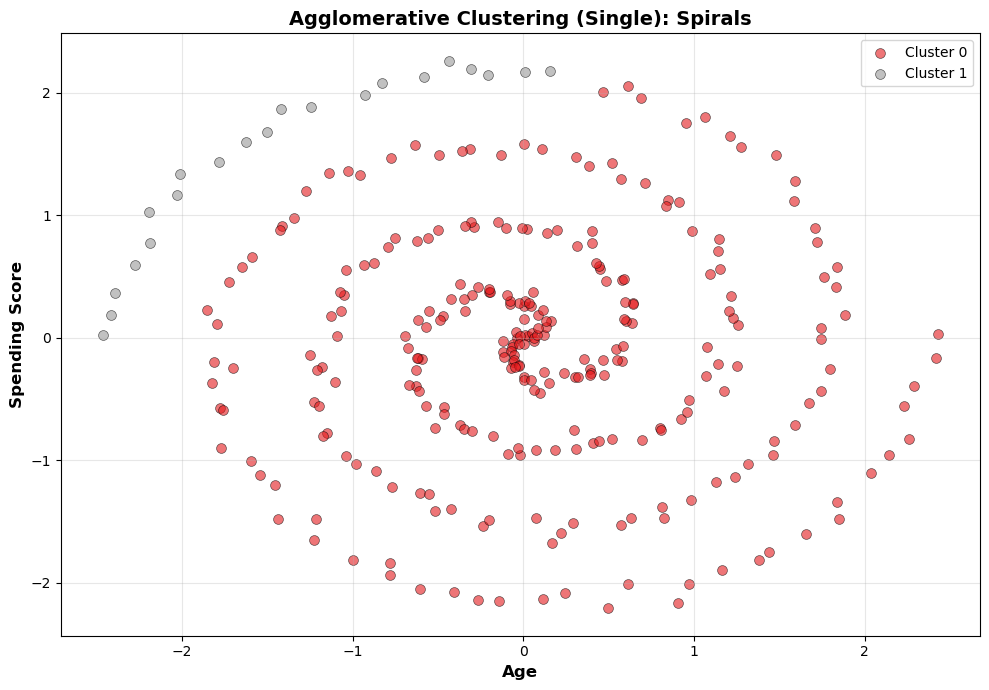


Agglomerative Clustering (linkage=complete):
  Cluster 0: 254 points
  Cluster 1: 46 points


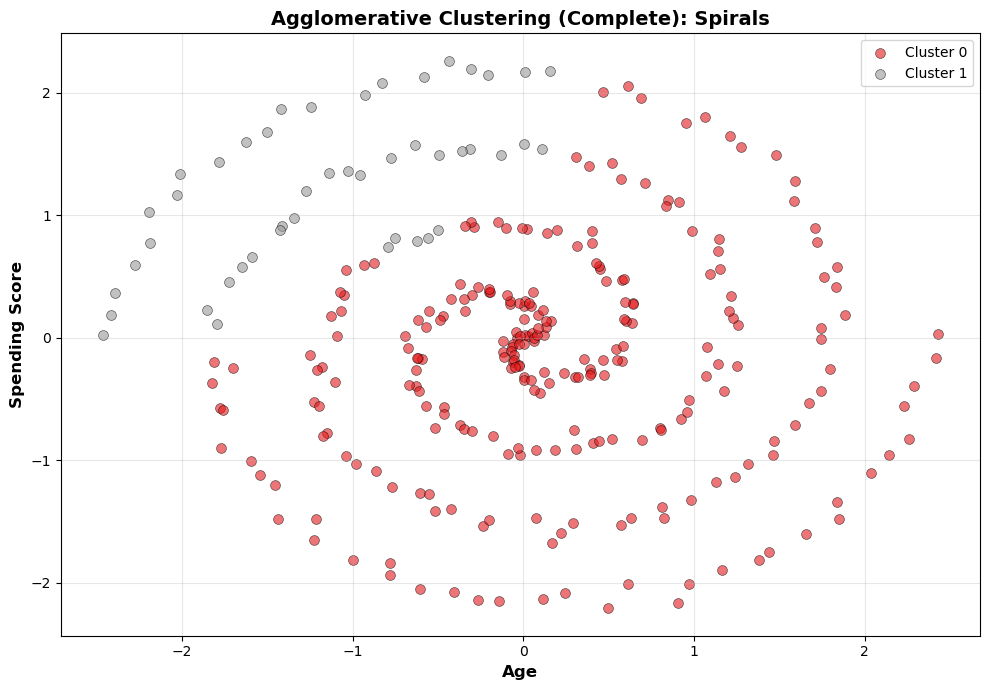


Agglomerative Clustering (linkage=average):
  Cluster 0: 245 points
  Cluster 1: 55 points


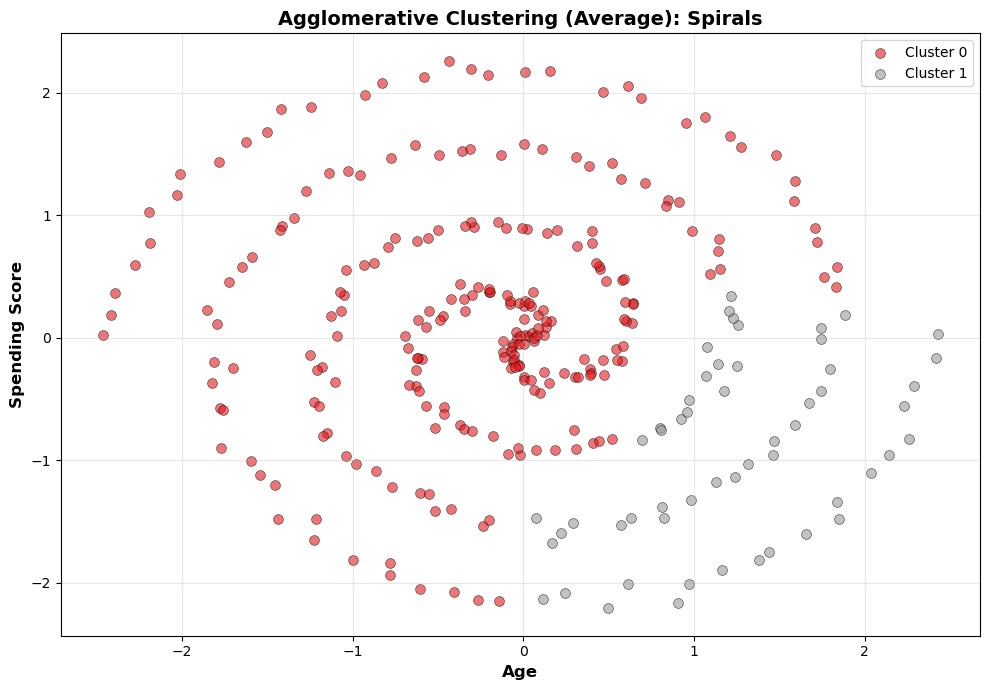


Agglomerative Clustering (linkage=ward):
  Cluster 0: 202 points
  Cluster 1: 98 points


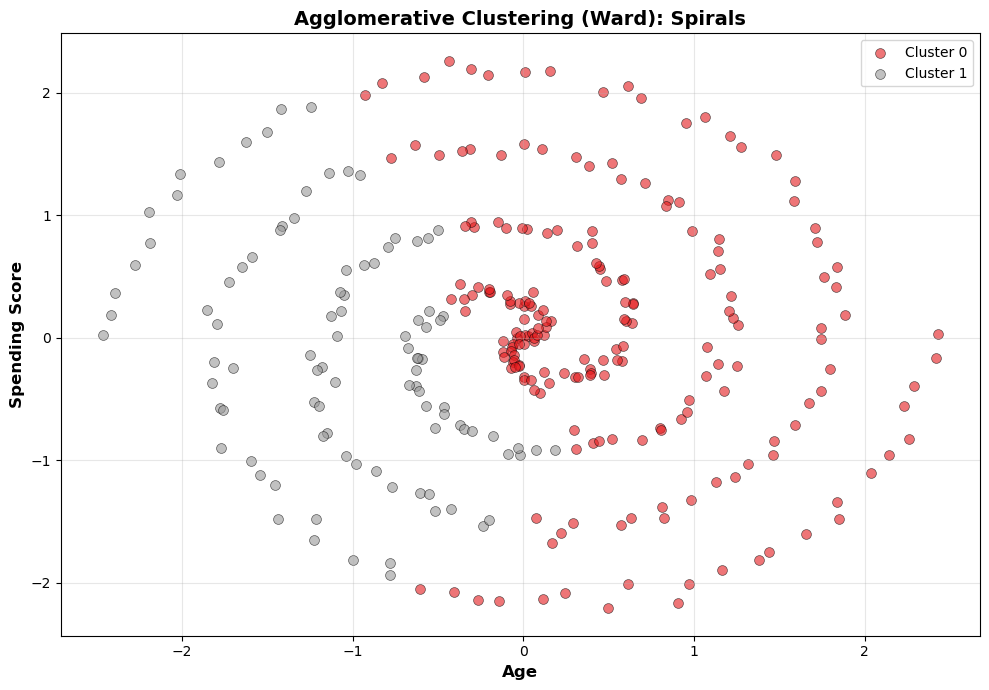


Agglomerative Clustering (linkage=single):
  Cluster 0: 283 points
  Cluster 1: 17 points


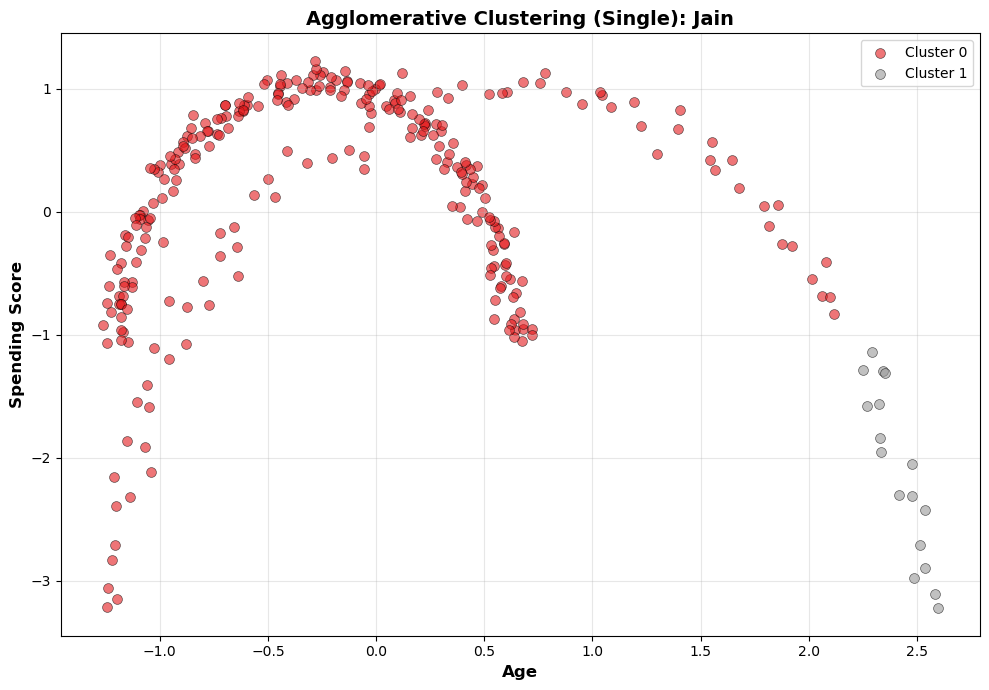


Agglomerative Clustering (linkage=complete):
  Cluster 0: 28 points
  Cluster 1: 272 points


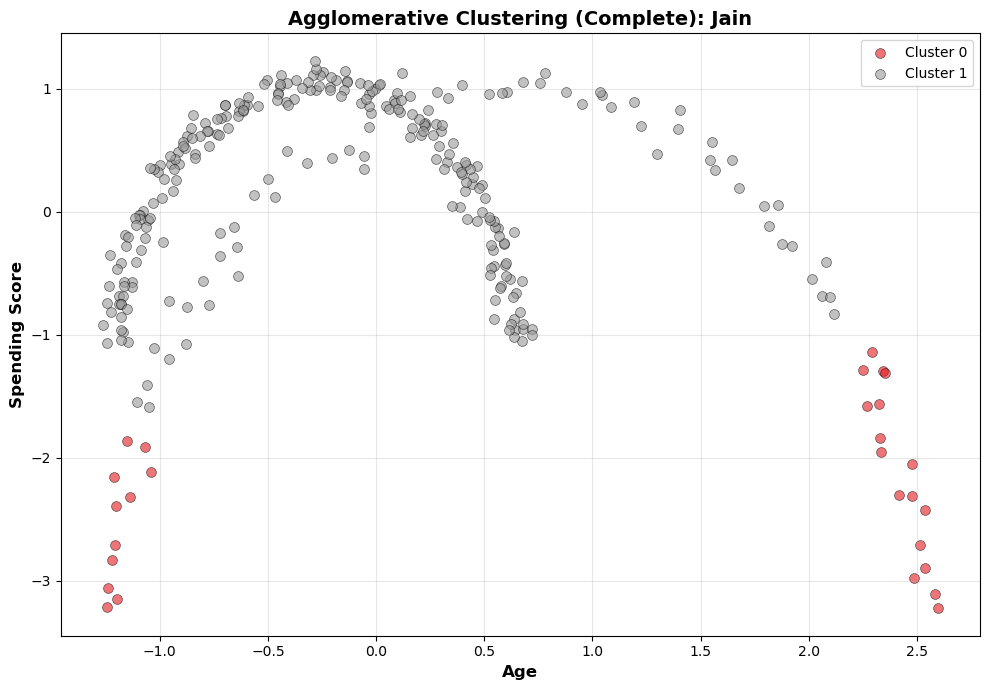


Agglomerative Clustering (linkage=average):
  Cluster 0: 276 points
  Cluster 1: 24 points


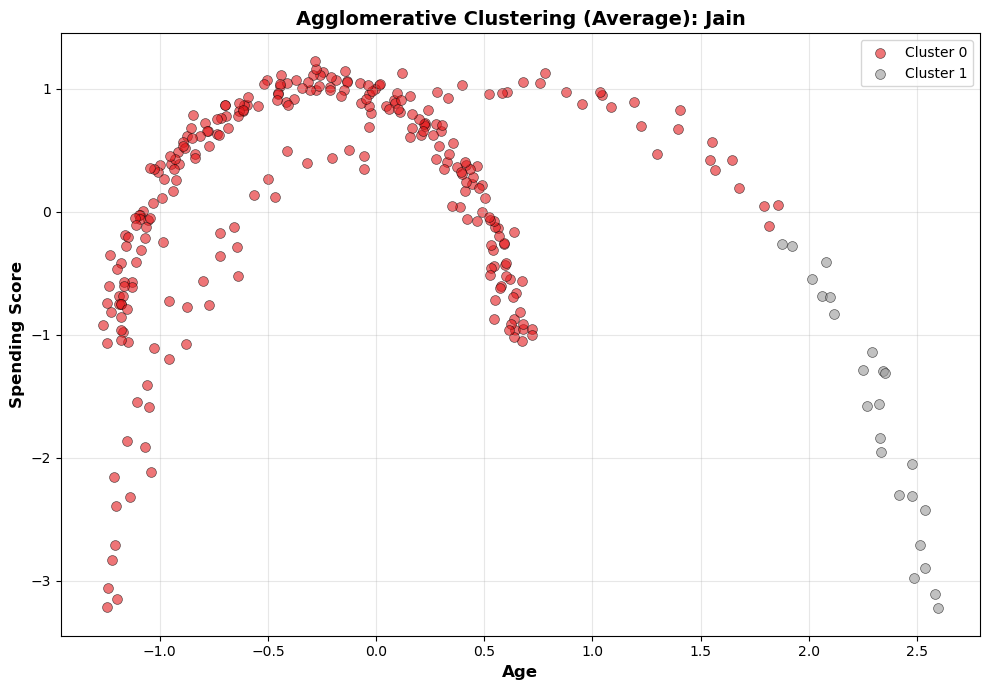


Agglomerative Clustering (linkage=ward):
  Cluster 0: 203 points
  Cluster 1: 97 points


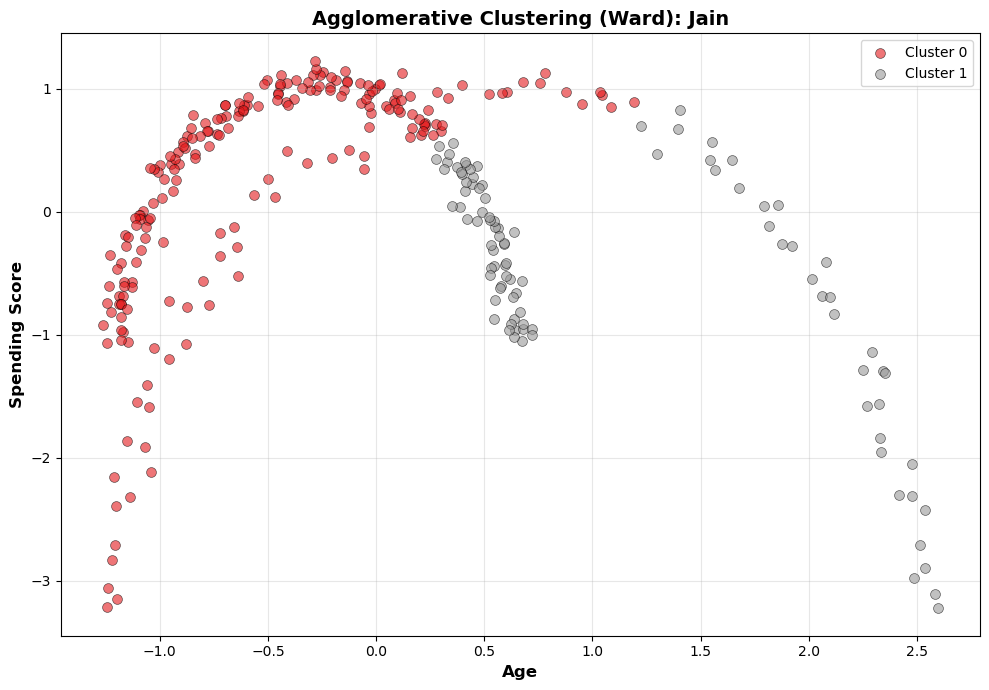


Agglomerative Clustering (linkage=single):
  Cluster 0: 299 points
  Cluster 1: 1 points


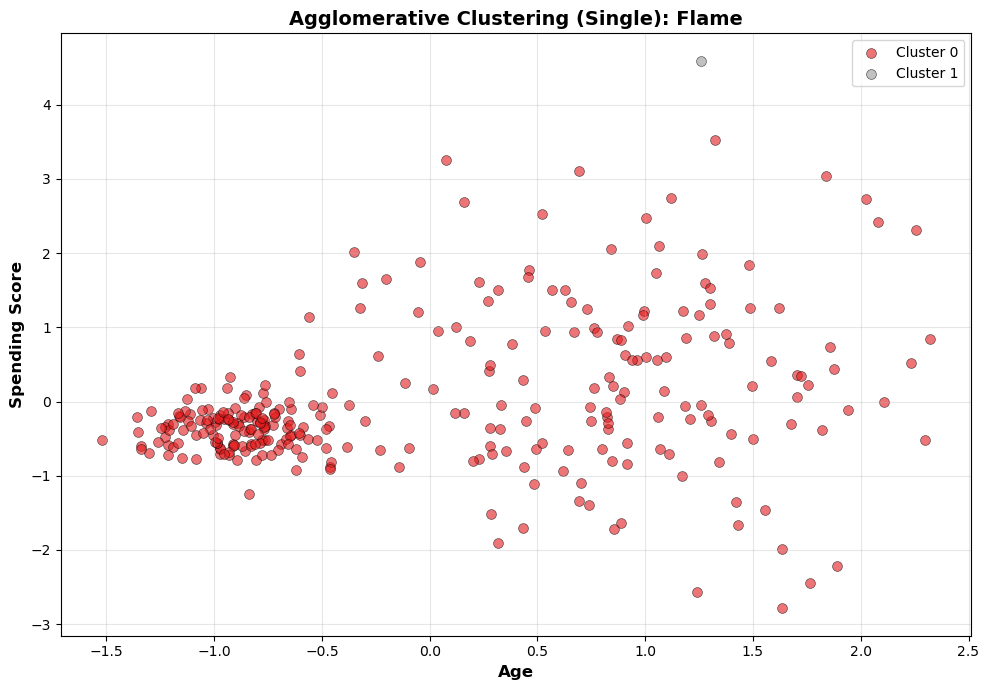


Agglomerative Clustering (linkage=complete):
  Cluster 0: 274 points
  Cluster 1: 26 points


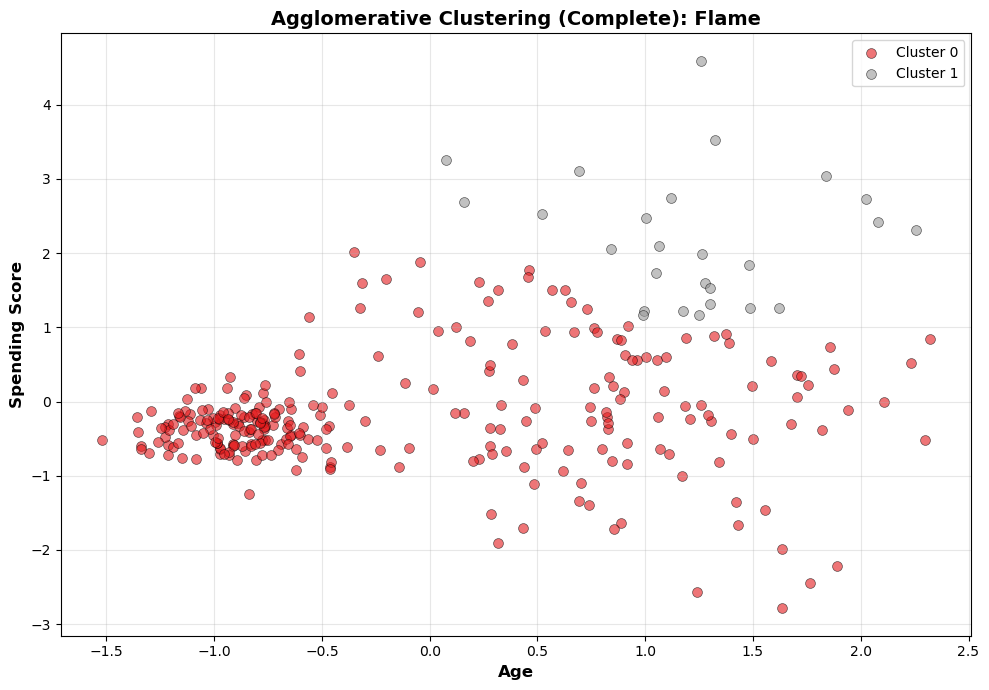


Agglomerative Clustering (linkage=average):
  Cluster 0: 298 points
  Cluster 1: 2 points


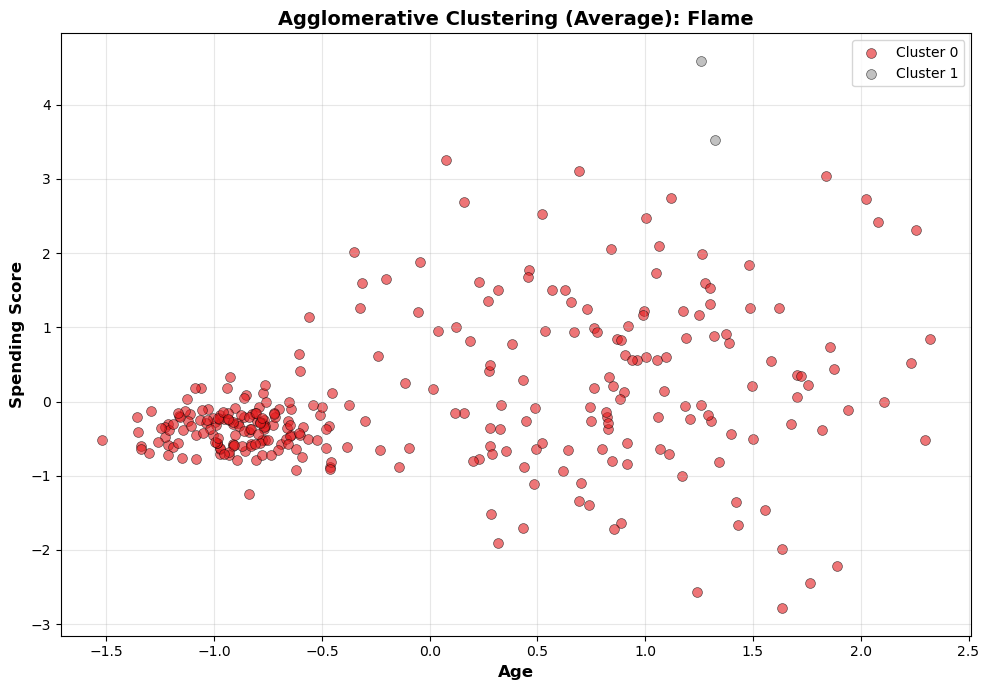


Agglomerative Clustering (linkage=ward):
  Cluster 0: 221 points
  Cluster 1: 79 points


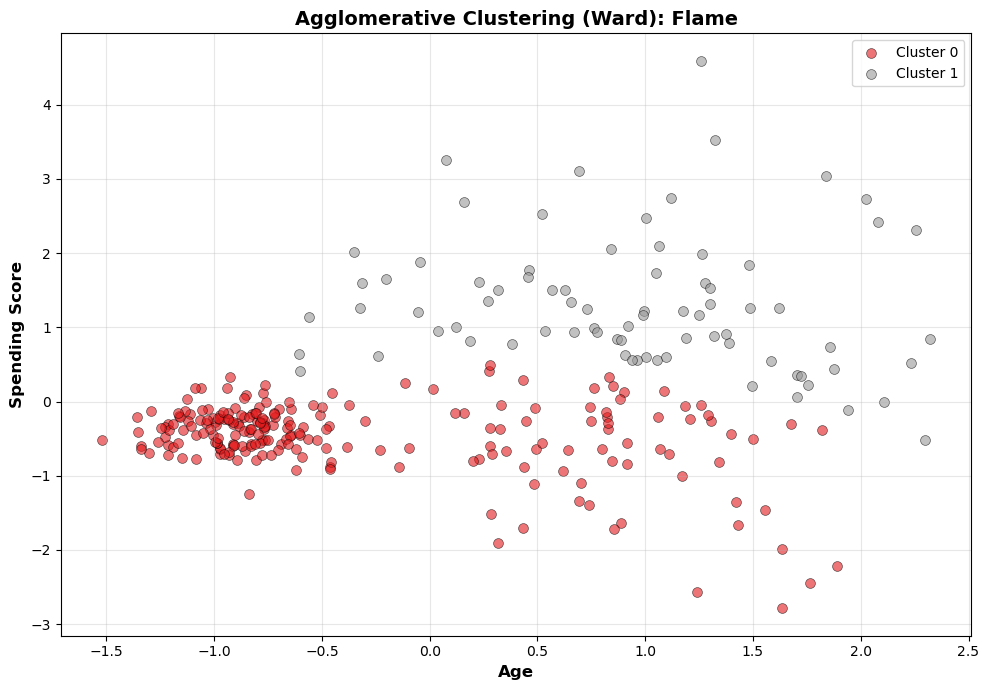


Agglomerative Clustering (linkage=single):
  Cluster 0: 51 points
  Cluster 1: 49 points
  Cluster 2: 50 points
  Cluster 3: 50 points
  Cluster 4: 50 points
  Cluster 5: 50 points


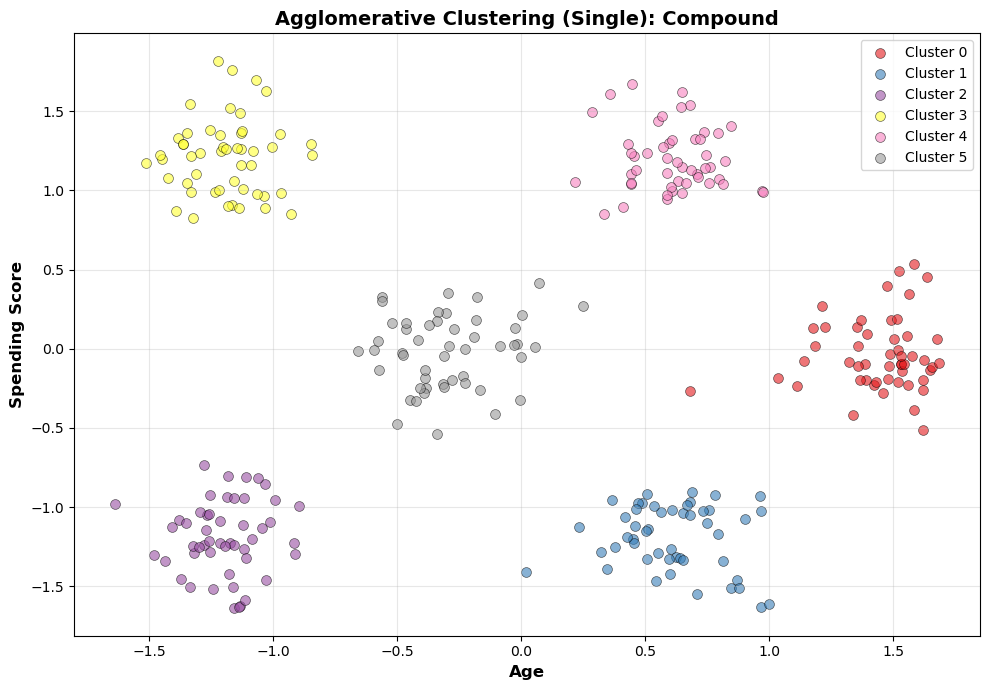


Agglomerative Clustering (linkage=complete):
  Cluster 0: 51 points
  Cluster 1: 49 points
  Cluster 2: 50 points
  Cluster 3: 50 points
  Cluster 4: 50 points
  Cluster 5: 50 points


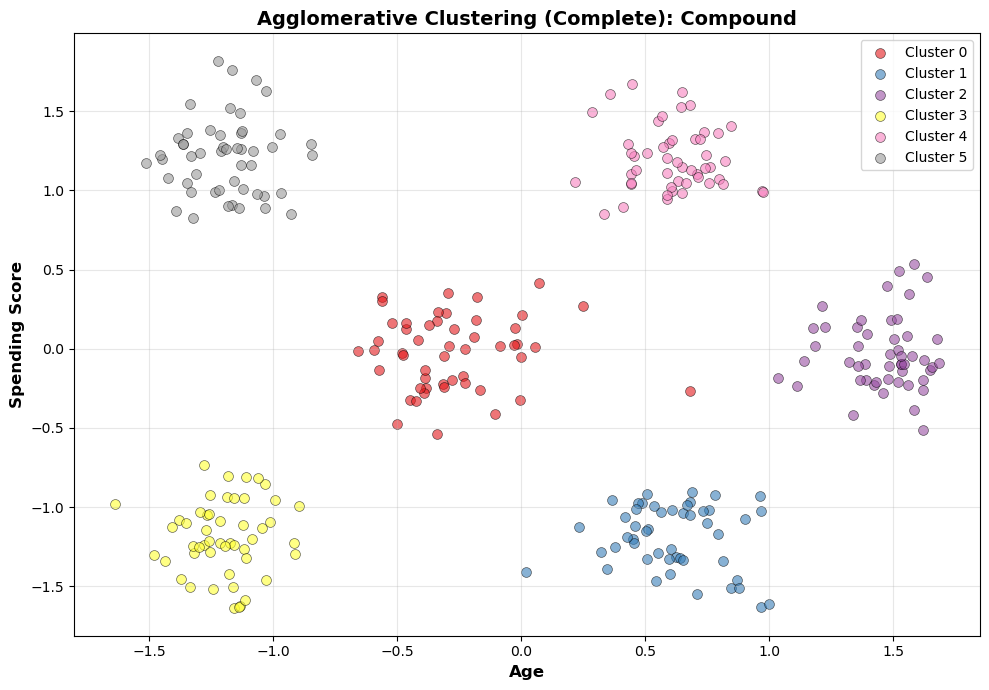


Agglomerative Clustering (linkage=average):
  Cluster 0: 51 points
  Cluster 1: 50 points
  Cluster 2: 49 points
  Cluster 3: 50 points
  Cluster 4: 50 points
  Cluster 5: 50 points


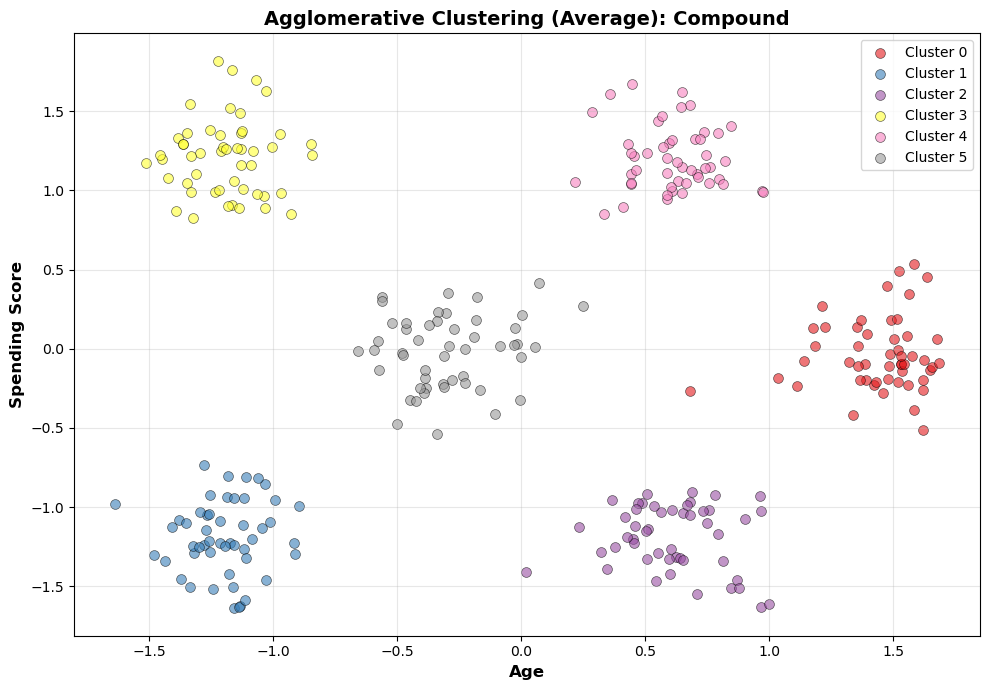


Agglomerative Clustering (linkage=ward):
  Cluster 0: 50 points
  Cluster 1: 50 points
  Cluster 2: 51 points
  Cluster 3: 50 points
  Cluster 4: 50 points
  Cluster 5: 49 points


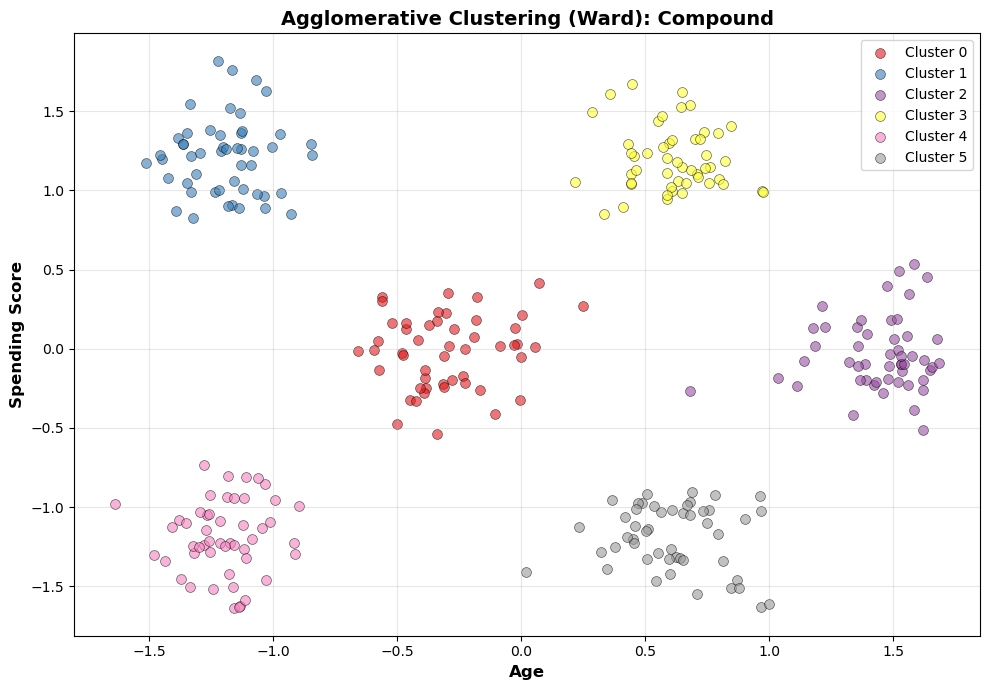


Agglomerative Clustering (linkage=single):
  Cluster 0: 150 points
  Cluster 1: 150 points


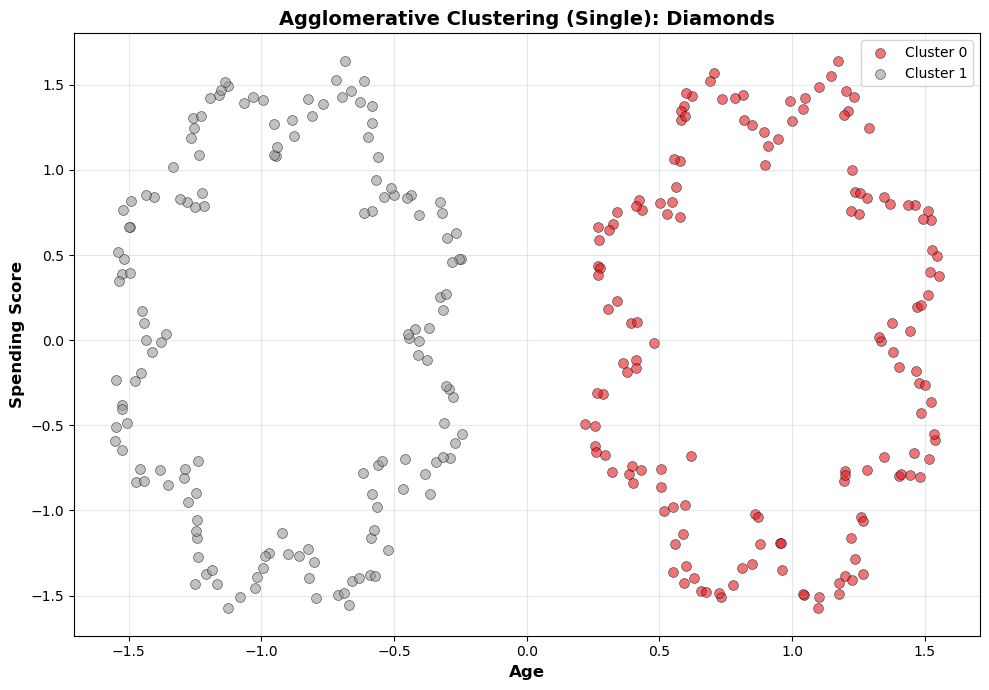


Agglomerative Clustering (linkage=complete):
  Cluster 0: 162 points
  Cluster 1: 138 points


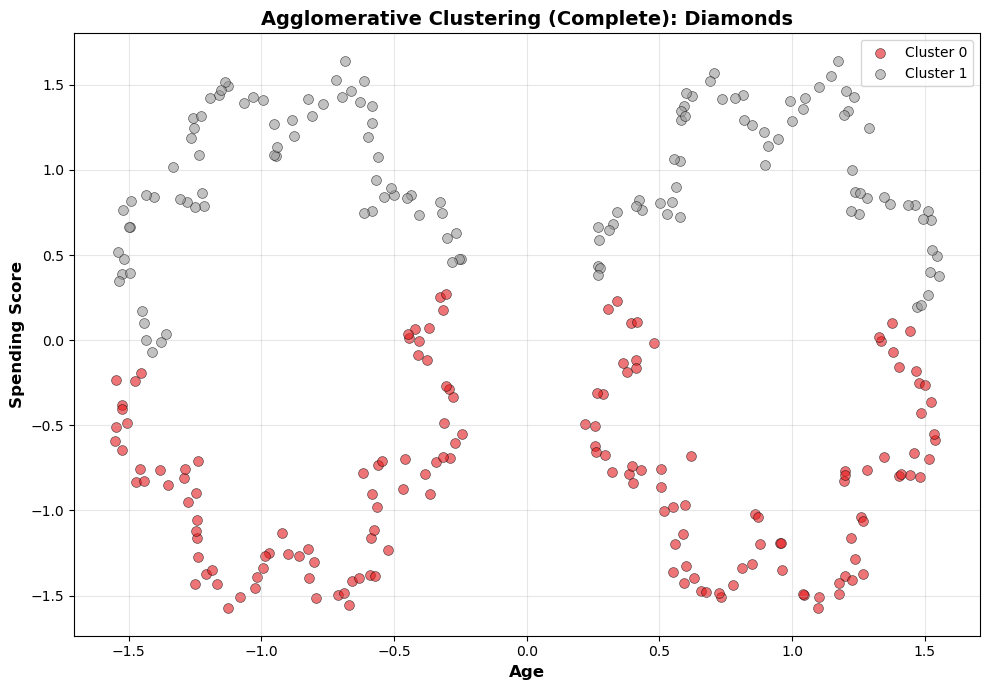


Agglomerative Clustering (linkage=average):
  Cluster 0: 132 points
  Cluster 1: 168 points


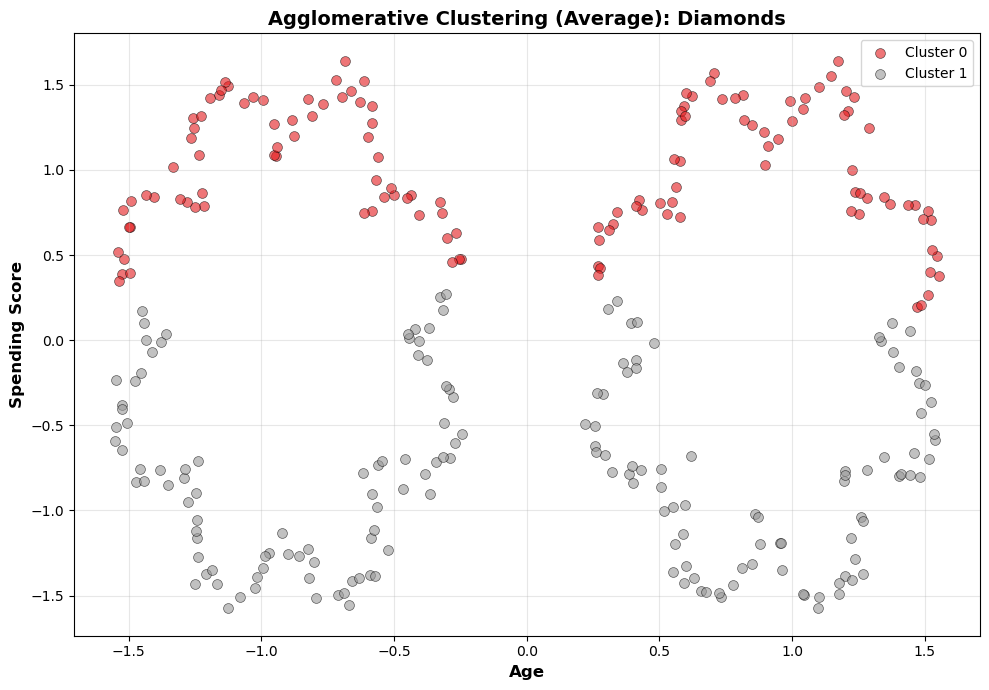


Agglomerative Clustering (linkage=ward):
  Cluster 0: 158 points
  Cluster 1: 142 points


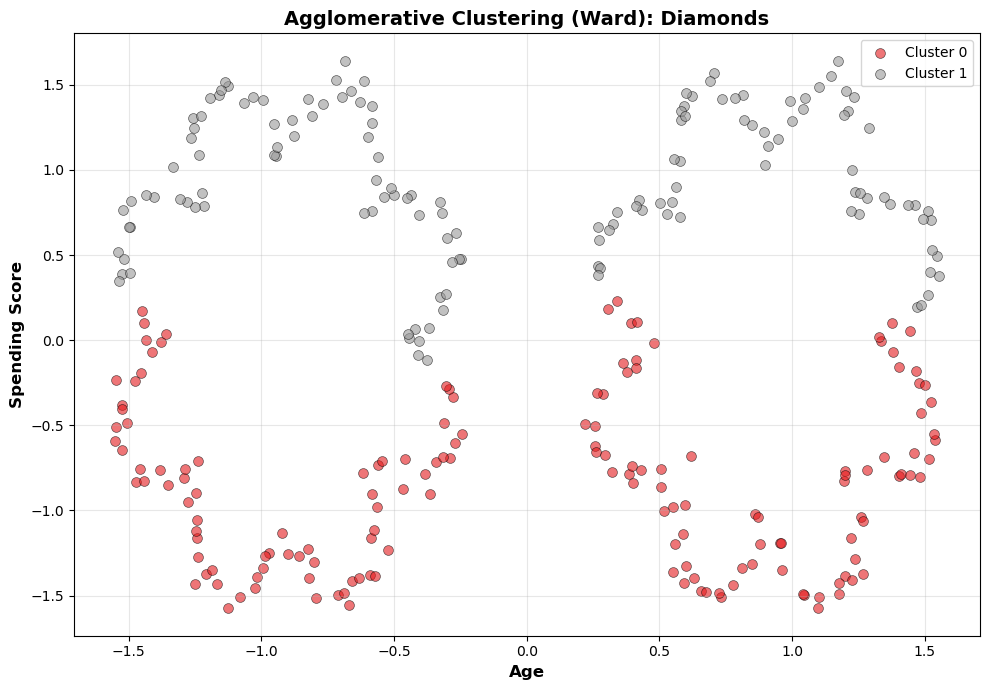


Agglomerative Clustering (linkage=single):
  Cluster 0: 284 points
  Cluster 1: 16 points


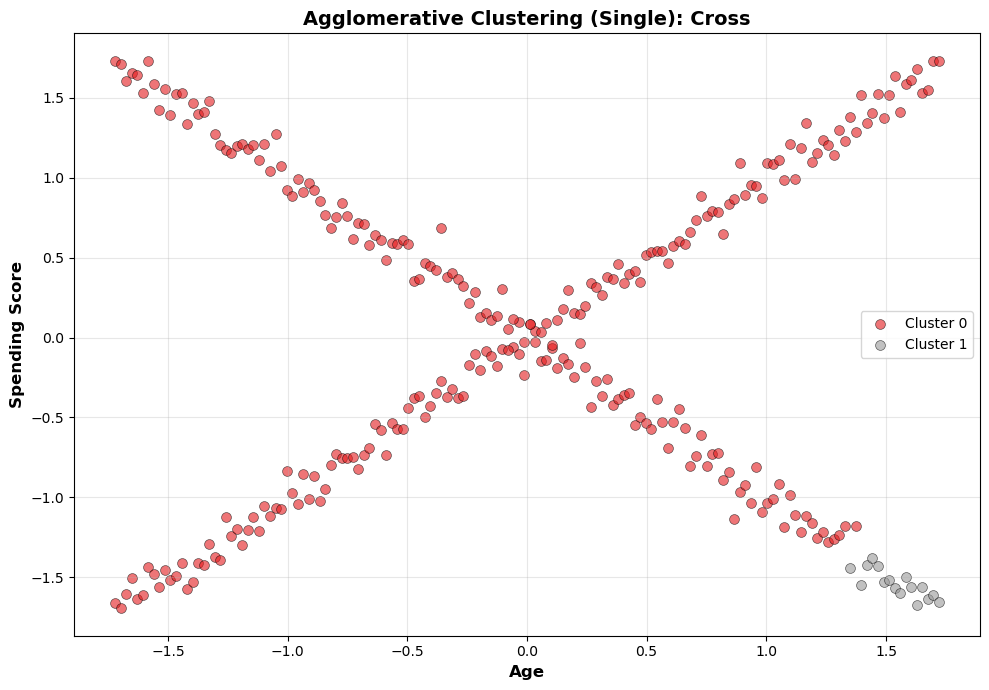


Agglomerative Clustering (linkage=complete):
  Cluster 0: 136 points
  Cluster 1: 164 points


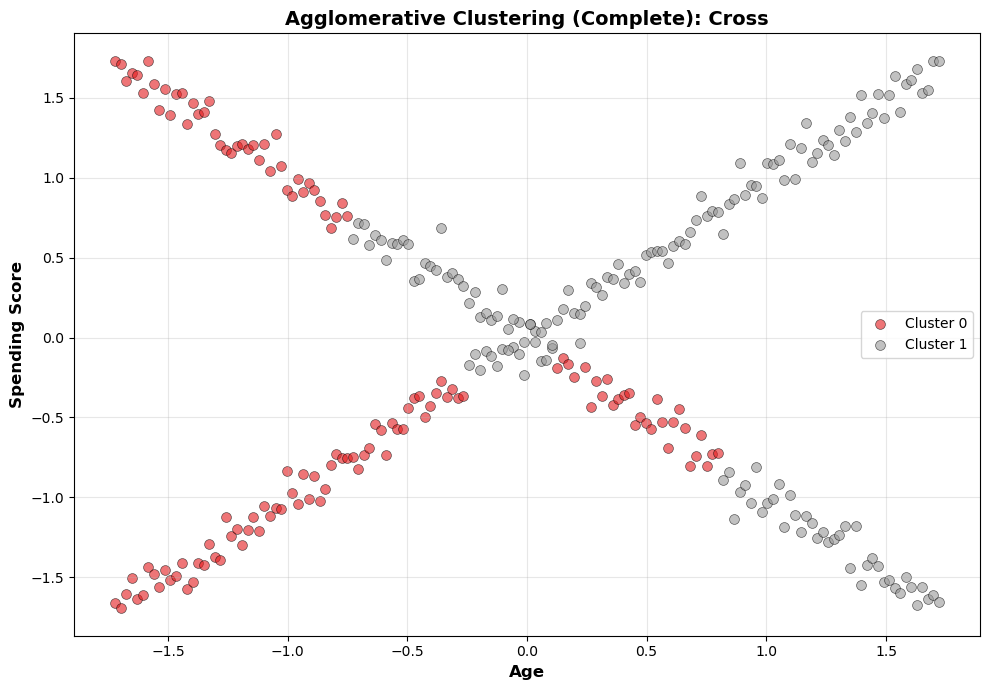


Agglomerative Clustering (linkage=average):
  Cluster 0: 261 points
  Cluster 1: 39 points


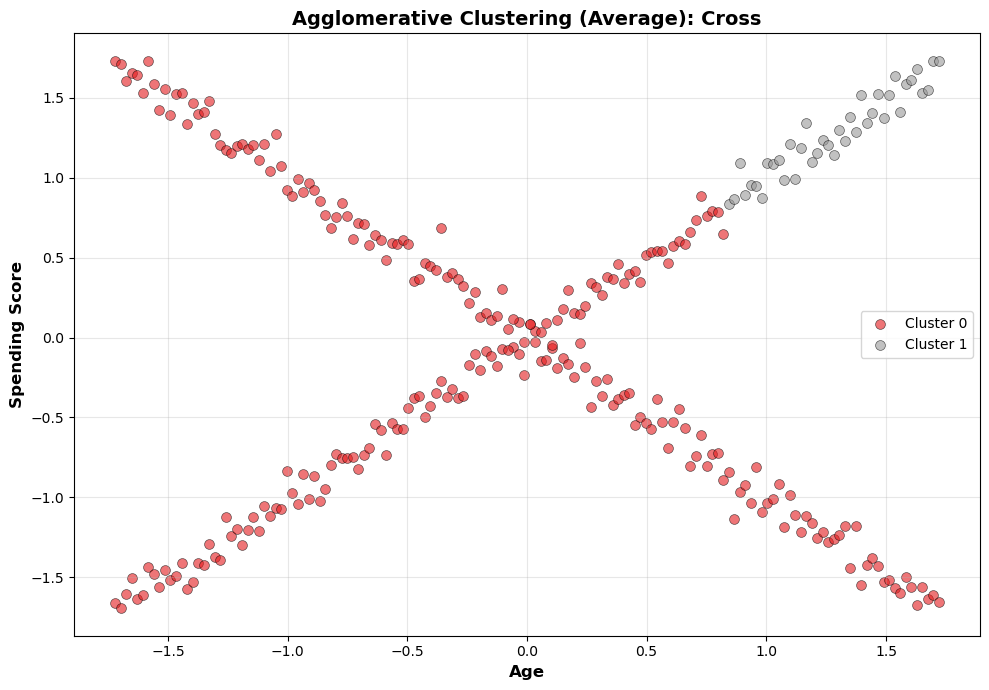


Agglomerative Clustering (linkage=ward):
  Cluster 0: 102 points
  Cluster 1: 198 points


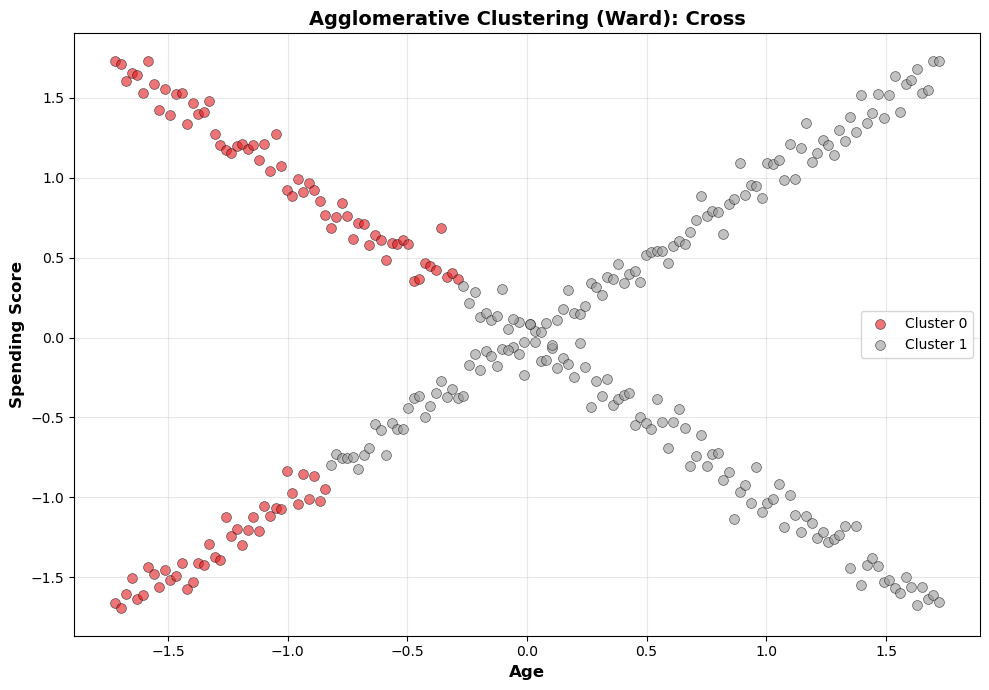


Agglomerative Clustering (linkage=single):
  Cluster 0: 100 points
  Cluster 1: 100 points
  Cluster 2: 100 points


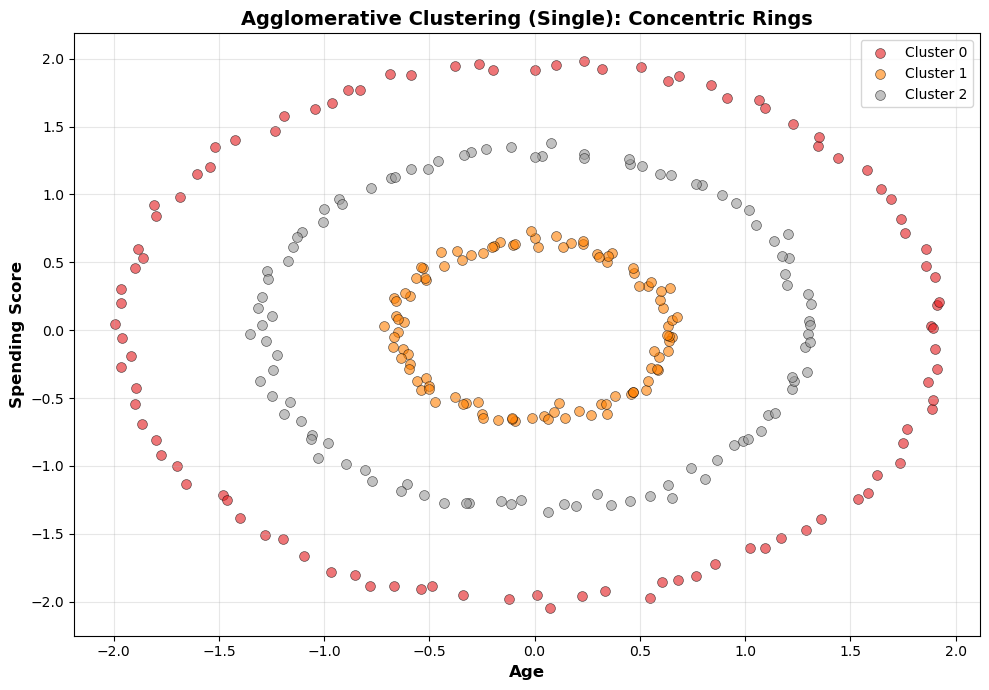


Agglomerative Clustering (linkage=complete):
  Cluster 0: 139 points
  Cluster 1: 86 points
  Cluster 2: 75 points


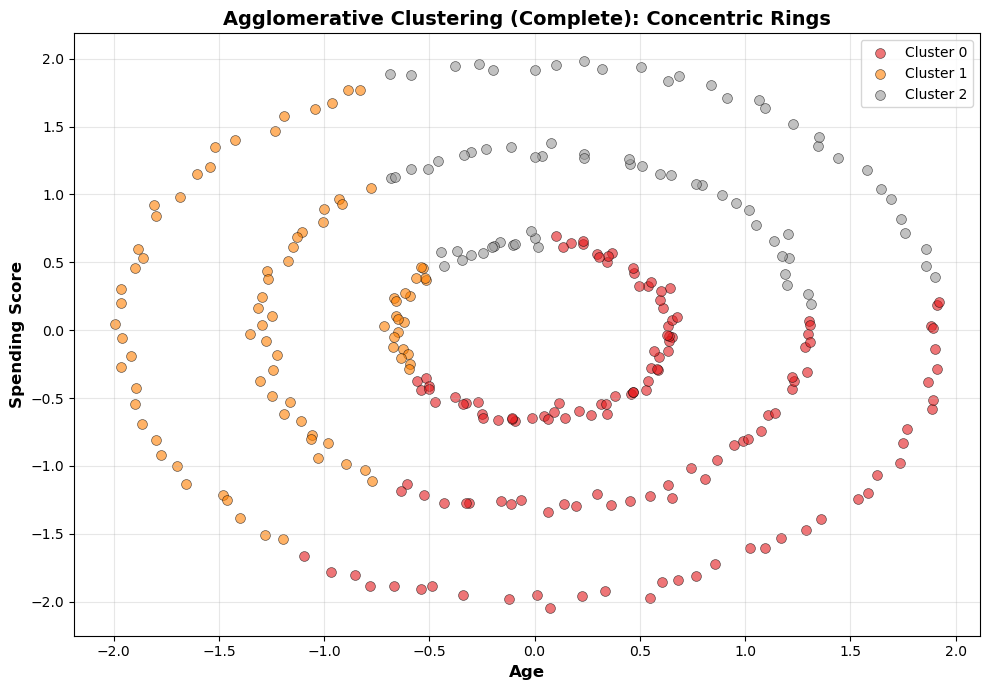


Agglomerative Clustering (linkage=average):
  Cluster 0: 187 points
  Cluster 1: 69 points
  Cluster 2: 44 points


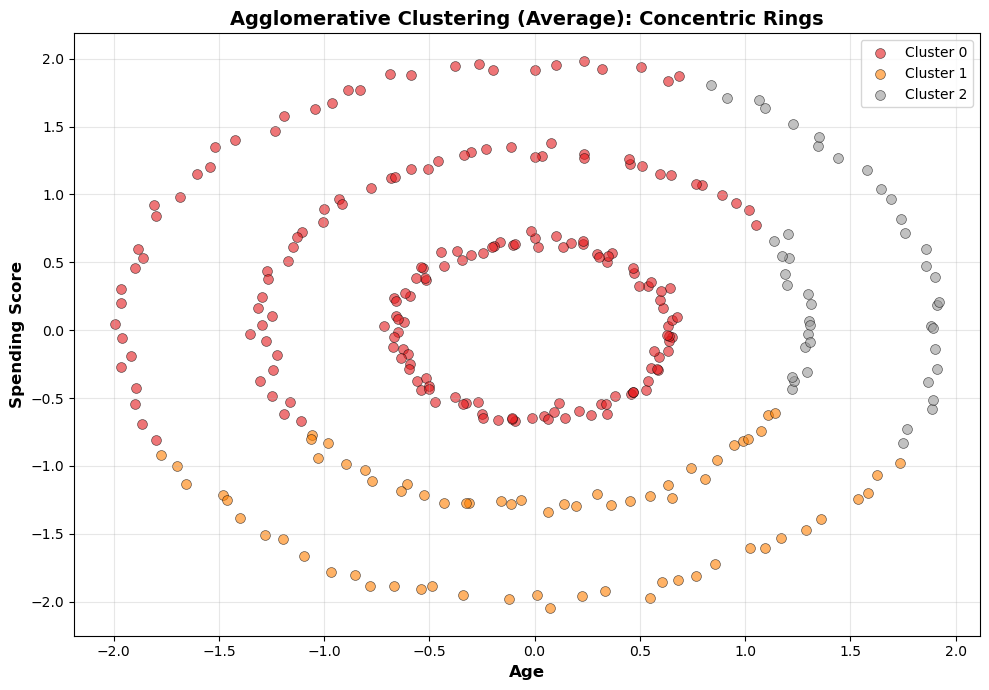


Agglomerative Clustering (linkage=ward):
  Cluster 0: 181 points
  Cluster 1: 71 points
  Cluster 2: 48 points


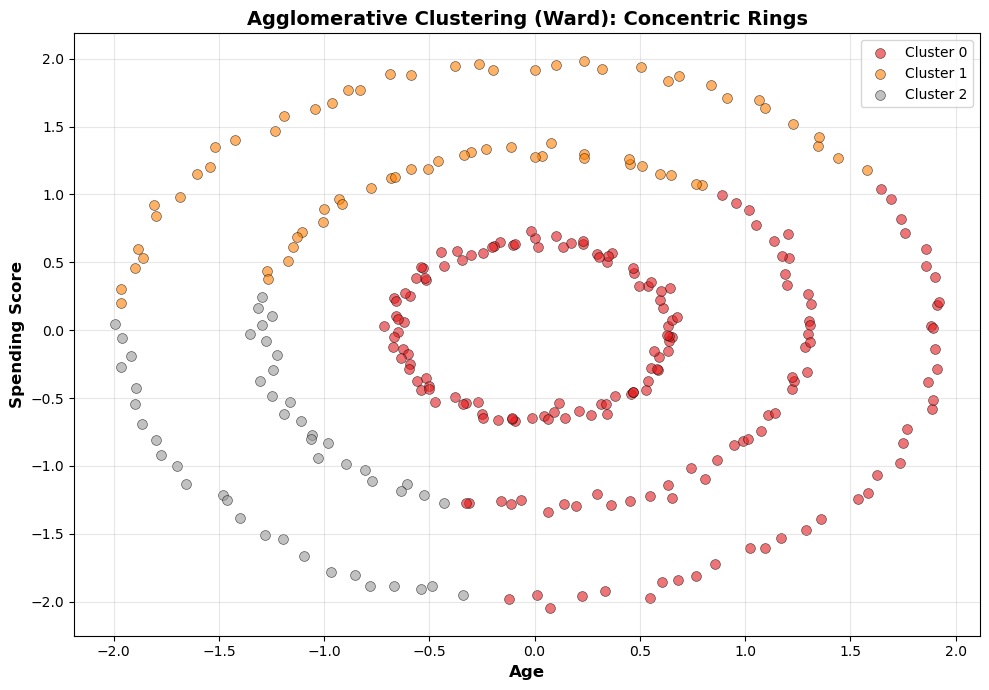


Agglomerative Clustering (linkage=single):
  Cluster 0: 299 points
  Cluster 1: 1 points


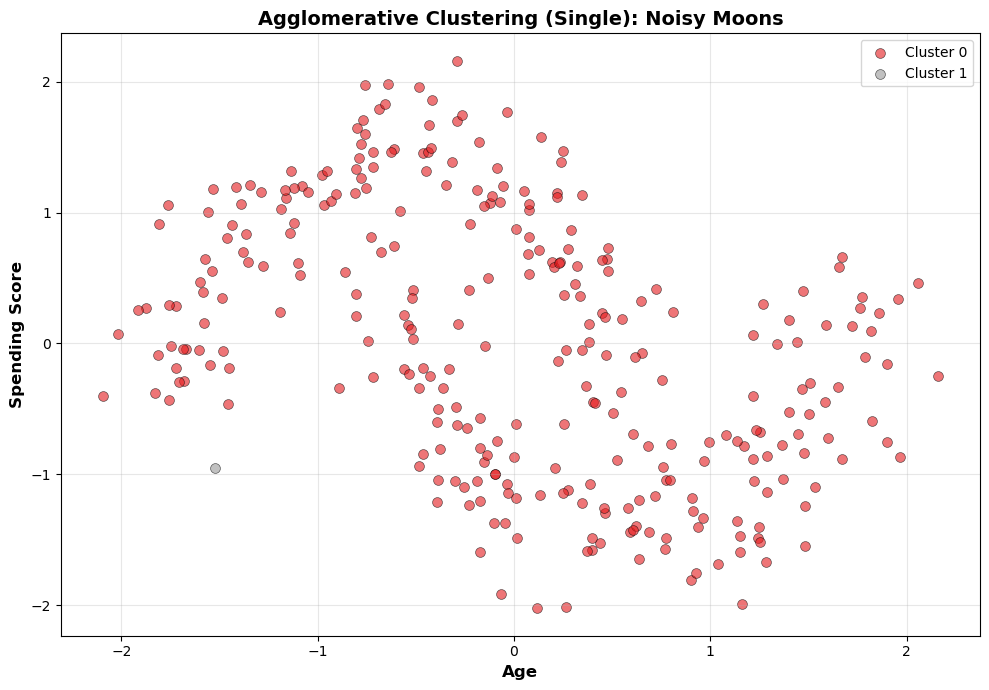


Agglomerative Clustering (linkage=complete):
  Cluster 0: 178 points
  Cluster 1: 122 points


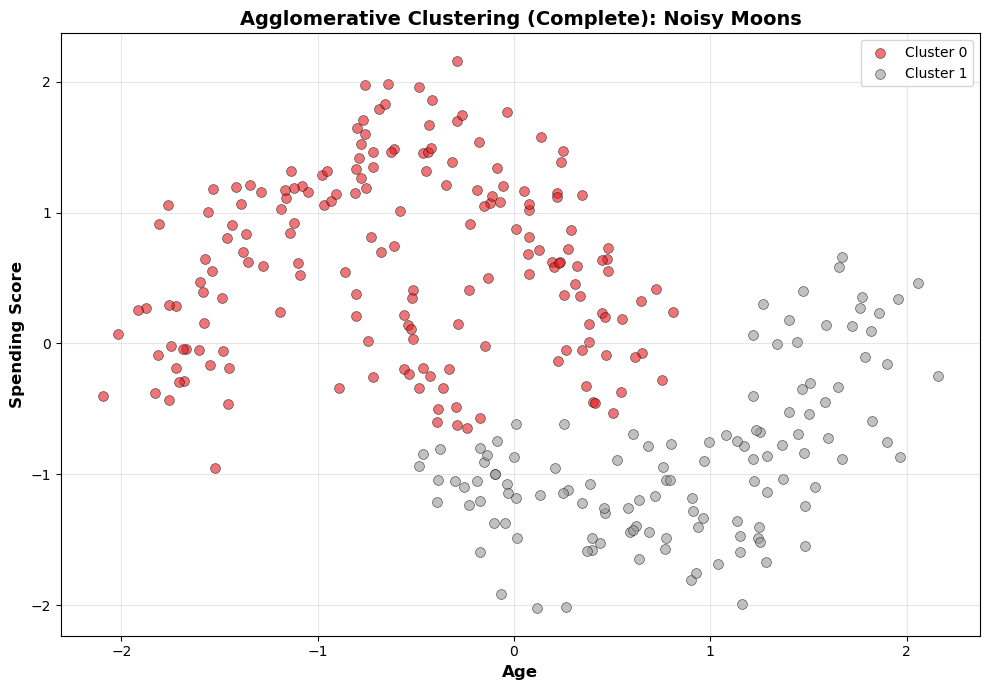


Agglomerative Clustering (linkage=average):
  Cluster 0: 174 points
  Cluster 1: 126 points


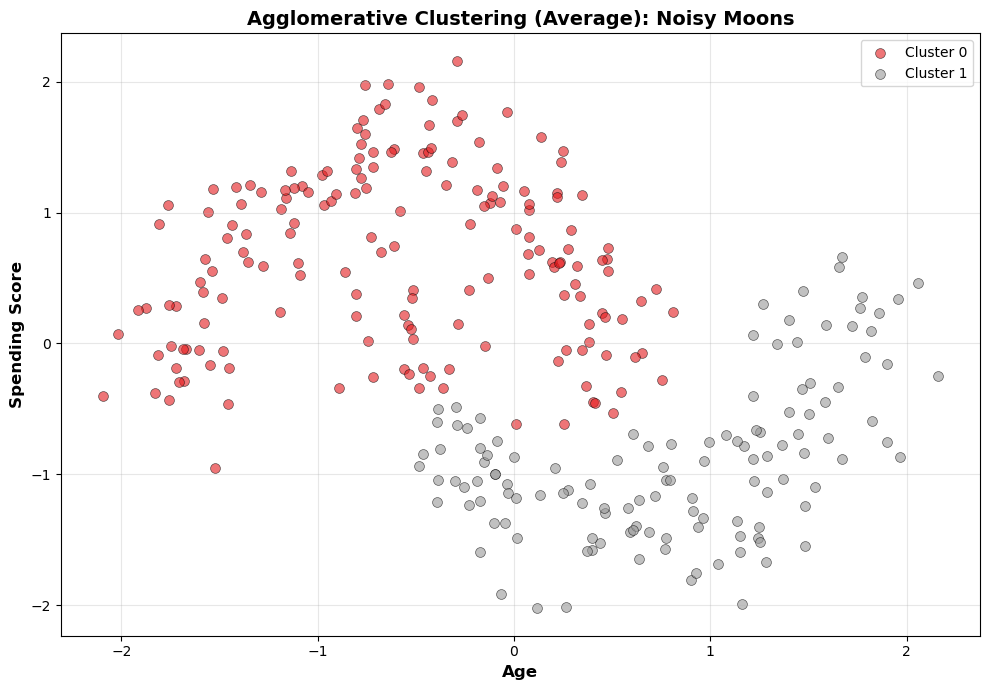


Agglomerative Clustering (linkage=ward):
  Cluster 0: 206 points
  Cluster 1: 94 points


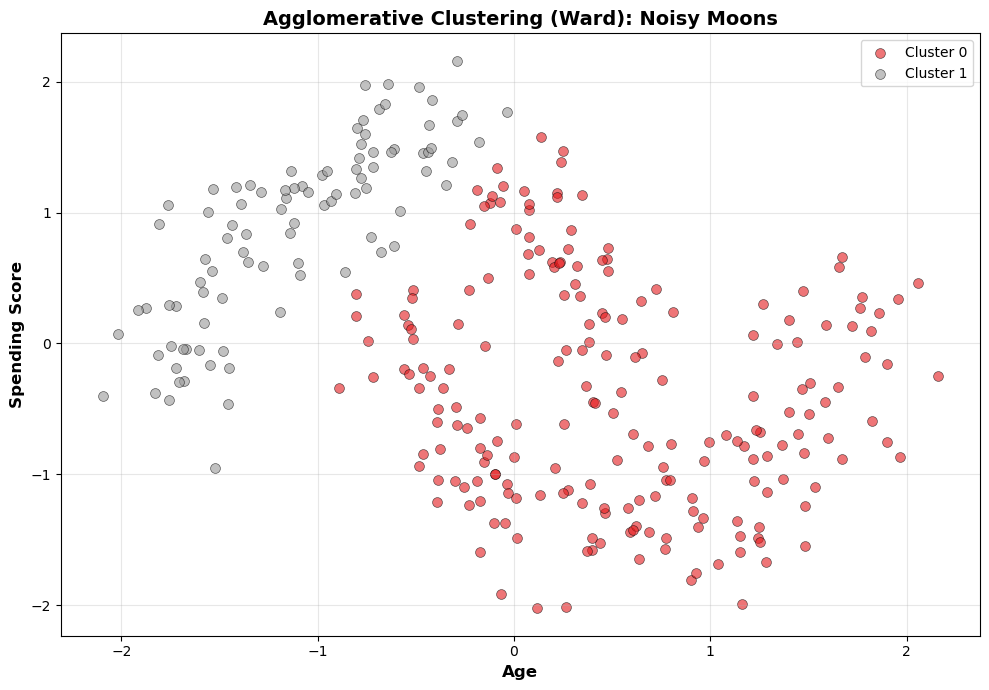


Agglomerative Clustering (linkage=single):
  Cluster 0: 160 points
  Cluster 1: 70 points
  Cluster 2: 70 points


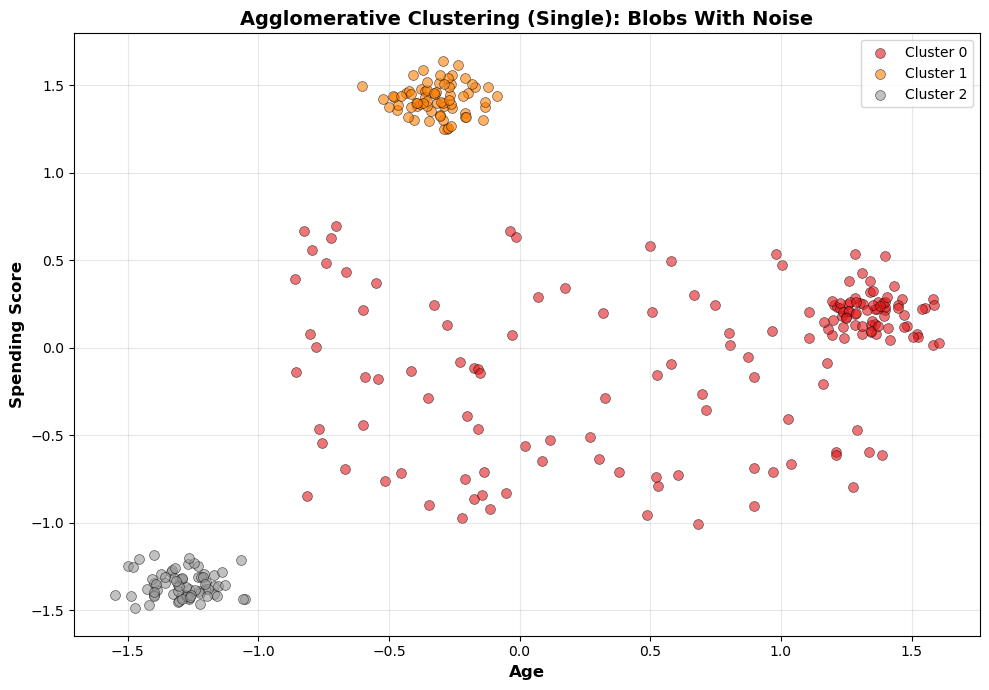


Agglomerative Clustering (linkage=complete):
  Cluster 0: 101 points
  Cluster 1: 90 points
  Cluster 2: 109 points


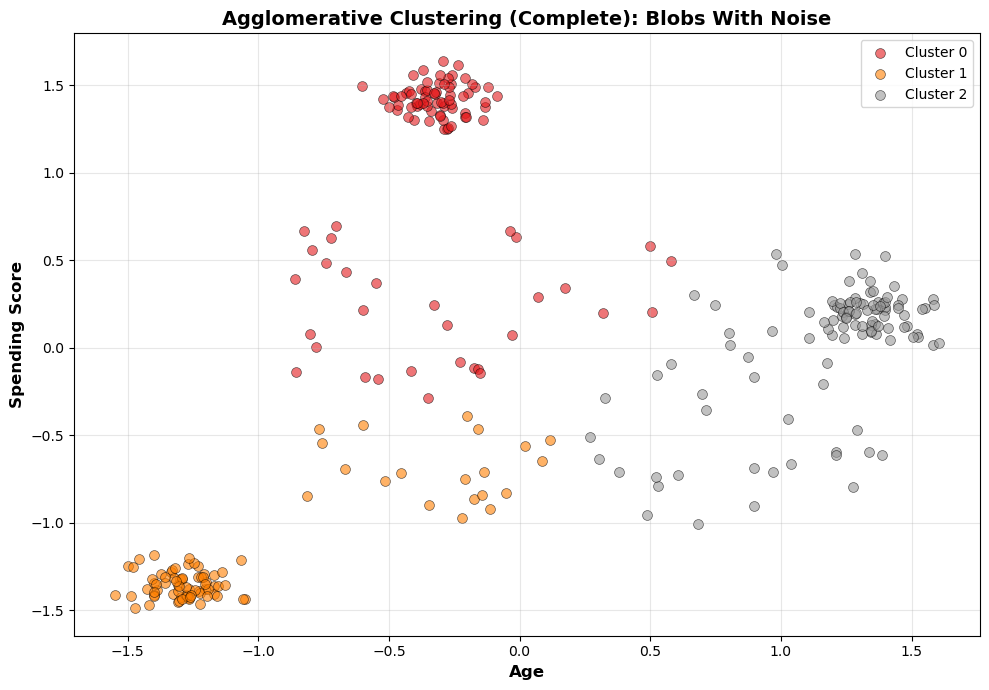


Agglomerative Clustering (linkage=average):
  Cluster 0: 110 points
  Cluster 1: 120 points
  Cluster 2: 70 points


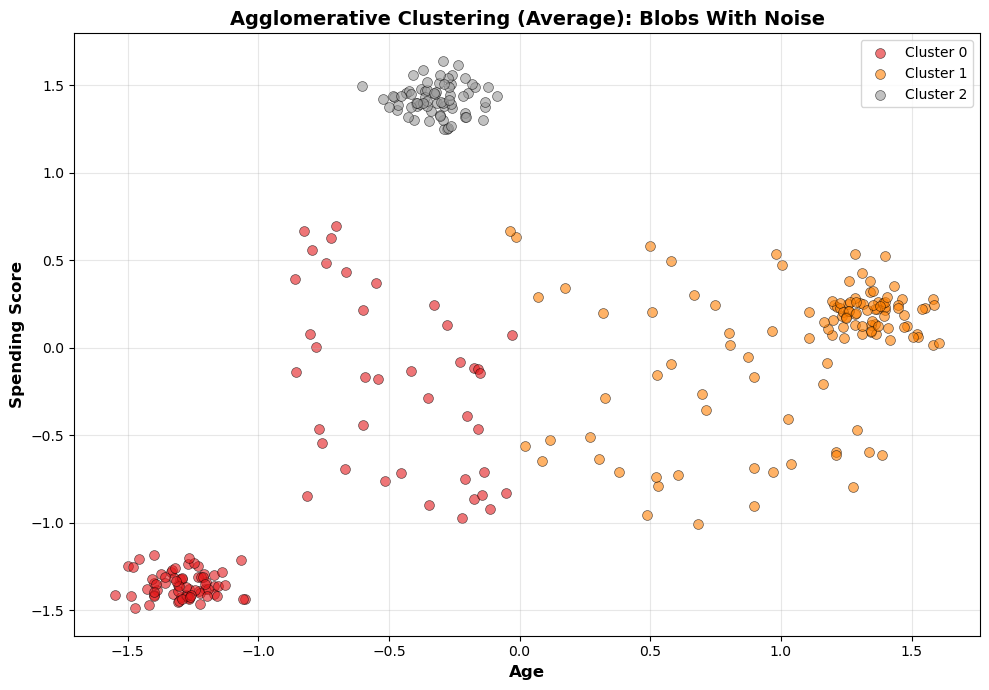


Agglomerative Clustering (linkage=ward):
  Cluster 0: 120 points
  Cluster 1: 70 points
  Cluster 2: 110 points


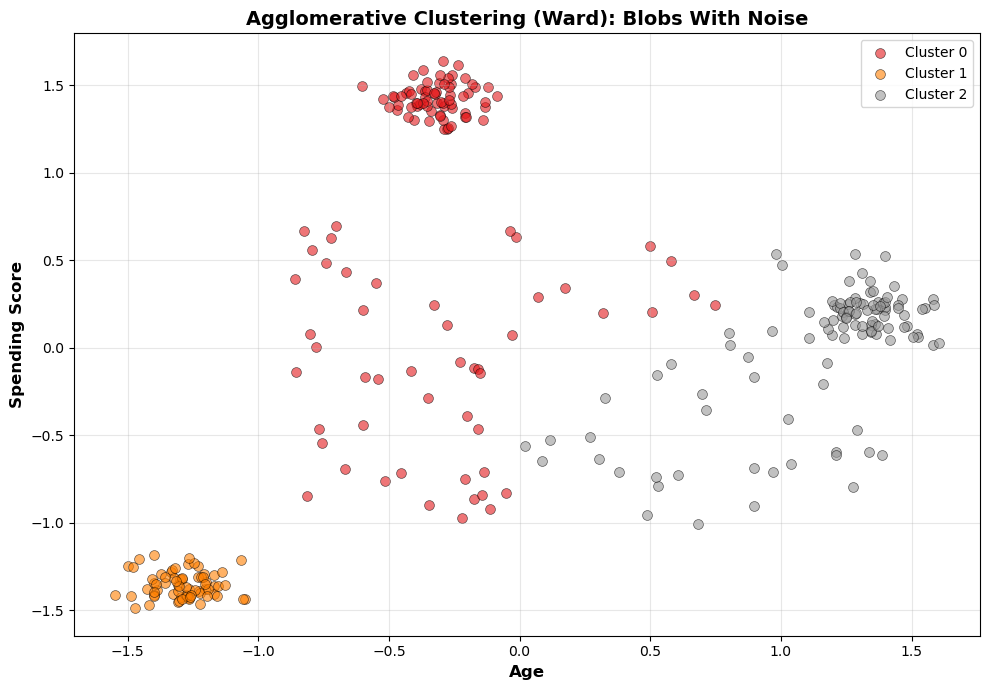

In [11]:
if __name__ == "__main__":
    
    # List of all datasets to test
    dataset_types = [
        'circles', 'moons', 'anisotropic', 'varied_density', 'blobs', 'random',
        'spirals', 'jain', 'flame', 'compound', 'diamonds', 'cross',
        'concentric_rings', 'noisy_moons', 'blobs_with_noise'
    ]
    
    print("\n" + "=" * 80)
    print("CLUSTERING COMPARISON: Hierarchical vs Partitional Methods")
    print(f"Testing {len(dataset_types)} different dataset types")
    print("=" * 80)
    
    # Option 1: View all original datasets first
    print("\n📊 Showing all original datasets...")
    n_datasets = len(dataset_types)
    n_cols = 5
    n_rows = (n_datasets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()
    
    for i, dataset_type in enumerate(dataset_types):
        gen = DatasetGenerator(dataset_type, n_samples=300)
        gen.generate()
        X, y, k = gen.get_data()
        
        axes[i].scatter(X[:, 0], X[:, 1], c='steelblue', s=30, alpha=0.6,
                       edgecolors='black', linewidth=0.3)
        axes[i].set_title(dataset_type.replace('_', ' ').title(),
                         fontsize=11, fontweight='bold')
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_aspect('equal', adjustable='box')
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    
    # Hide unused subplots
    for i in range(n_datasets, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Gallery of All Available Datasets', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # Apply all types agglomerative clustering (single, complete, average, ward) to all dataset types and plot each in their own figure
    for i, dataset_type in enumerate(dataset_types):
        gen = DatasetGenerator(dataset_type, n_samples=300)
        gen.generate()
        X, y, k = gen.get_data()
        
        labels = apply_agglomerative(X, n_clusters=k, linkage_type='single')
        plot_clusters(X, labels, f'Agglomerative Clustering (Single): {dataset_type.replace("_", " ").title()}')
        
        labels = apply_agglomerative(X, n_clusters=k, linkage_type='complete')
        plot_clusters(X, labels, f'Agglomerative Clustering (Complete): {dataset_type.replace("_", " ").title()}')
        
        labels = apply_agglomerative(X, n_clusters=k, linkage_type='average')
        plot_clusters(X, labels, f'Agglomerative Clustering (Average): {dataset_type.replace("_", " ").title()}')
        
        labels = apply_agglomerative(X, n_clusters=k, linkage_type='ward')
        plot_clusters(X, labels, f'Agglomerative Clustering (Ward): {dataset_type.replace("_", " ").title()}')
    
    
